# Import thư viện

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

# Import Data

In [2]:
# Lấy danh sách các station từ file air
air_files = glob.glob('data/raw/air/*.csv')
station_numbers = sorted([int(f.split('_')[-1].replace('.csv', '')) for f in air_files])

print(f"Found {len(station_numbers)} stations: {station_numbers}")

# Mảng lưu trữ dataframe của từng station
station_dataframes = []

# Ghép từng cặp file air và weather tương ứng
for station_num in station_numbers:
    # Đọc file air và weather cho từng station
    air_file = f'data/raw/air/air_{station_num}.csv'
    weather_file = f'data/raw/weather/weather_{station_num}.csv'
    
    # Kiểm tra file tồn tại
    if os.path.exists(air_file) and os.path.exists(weather_file):
        # Đọc dữ liệu
        air_df = pd.read_csv(air_file)
        weather_df = pd.read_csv(weather_file)
        
        # Convert time columns to datetime
        air_df['timestamp_local'] = pd.to_datetime(air_df['timestamp_local'])
        weather_df['time'] = pd.to_datetime(weather_df['time'])
        
        # Sort theo thời gian trước khi merge
        air_df = air_df.sort_values('timestamp_local').reset_index(drop=True)
        weather_df = weather_df.sort_values('time').reset_index(drop=True)
        
        # Filter time range: 00:00:00 1/1/2023 - 00:00:00 1/12/2025
        start_time = datetime.datetime(2023, 1, 1, 0, 0, 0)
        end_time = datetime.datetime(2025, 12, 1, 0, 0, 0)
        
        air_df = air_df[(air_df['timestamp_local'] >= start_time) & (air_df['timestamp_local'] <= end_time)]
        weather_df = weather_df[(weather_df['time'] >= start_time) & (weather_df['time'] <= end_time)]
        
        # Merge air và weather theo time
        merged = pd.merge(air_df, weather_df, 
                         left_on='timestamp_local', 
                         right_on='time', 
                         how='inner', 
                         suffixes=('_air', '_weather'))
        
        # Drop cột 'time' từ weather (duplicate), chỉ giữ timestamp_local
        if 'time' in merged.columns:
            merged = merged.drop(columns=['time'])
        
        # Rename timestamp_local thành time
        merged = merged.rename(columns={'timestamp_local': 'time'})
        
        # Thêm thông tin station
        merged['station'] = station_num
        
        # Sort lại theo thời gian
        merged = merged.sort_values('time').reset_index(drop=True)
        
        # Lưu vào mảng
        station_dataframes.append(merged)
        
        print(f"Station {station_num}: Air {len(air_df)} rows, Weather {len(weather_df)} rows, Merged {len(merged)} rows")
    else:
        print(f"Warning: Missing files for station {station_num}")

print(f"\n=== SUMMARY ===")
print(f"Total stations loaded: {len(station_dataframes)}")
print(f"\nExample - Station 1 shape: {station_dataframes[0].shape if len(station_dataframes) > 0 else 'N/A'}")
print(f"Example - Station 1 time range: {station_dataframes[0]['time'].min()} to {station_dataframes[0]['time'].max() if len(station_dataframes) > 0 else 'N/A'}")
print(f"\nFirst few rows of Station 1:")
if len(station_dataframes) > 0:
    print(station_dataframes[0].head())
    print(f"\nColumns: {station_dataframes[0].columns.tolist()}")

Found 32 stations: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Station 1: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 2: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 3: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 4: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 5: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 6: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 7: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 8: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 9: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 10: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 11: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 12: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 13: Air 25597 rows, Weather 25561 rows, Merged 25597 rows
Station 14: 

# Thay đổi tên thuộc tính và lấy các thuộc tính cần thiết

In [3]:
# Mapping tên cột (time đã được xử lý ở cell trước)
name_mapping = {
    'Target_City': 'city',
    'Target_District': 'district',
    'Target_Lat': 'latitude',
    'Target_Lon': 'longitude',
    'temperature_2m (°C)': 'temperature',
    'relative_humidity_2m (%)': 'humidity',
    'wind_speed_10m (m/s)': 'wind_speed',
    'wind_direction_10m (°)': 'wind_direction',
    'apparent_temperature (°C)': 'apparent_temperature',
    'precipitation (mm)': 'precipitation',
    'cloud_cover (%)': 'cloud_cover', 
    'wind_gusts_10m (m/s)': 'wind_gusts',
    'dew_point_2m (°C)': 'dew_point',
    'soil_temperature_0_to_7cm (°C)': 'soil_temp_0_7cm',
    'soil_temperature_7_to_28cm (°C)': 'soil_temp_7_28cm',
    'soil_temperature_28_to_100cm (°C)': 'soil_temp_28_100cm',
    'soil_temperature_100_to_255cm (°C)': 'soil_temp_100_255cm',
    'soil_moisture_0_to_7cm (m³/m³)': 'soil_moisture_0_7cm',
    'soil_moisture_7_to_28cm (m³/m³)': 'soil_moisture_7_28cm',
    'soil_moisture_28_to_100cm (m³/m³)': 'soil_moisture_28_100cm',
    'soil_moisture_100_to_255cm (m³/m³)': 'soil_moisture_100_255cm'}

# Thứ tự cột mong muốn
col_order = ['time', 
             'station', 
             'city', 
             'district', 
             'latitude', 
             'longitude',
             'aqi',
             'pm25',
             'pm10',
             'co',
             'no2',
             'o3',
             'so2',
             'temperature', 
             'humidity', 
             'dew_point',
             'apparent_temperature',
             'wind_speed', 
             'wind_direction',
             'wind_gusts',
             'precipitation',
             'cloud_cover',
             'soil_temp_0_7cm',
             'soil_temp_7_28cm',
             'soil_temp_28_100cm',
             'soil_temp_100_255cm',
             'soil_moisture_0_7cm',
             'soil_moisture_7_28cm',
             'soil_moisture_28_100cm',
             'soil_moisture_100_255cm',
             ]

# Áp dụng thay đổi cho từng station
for i in range(len(station_dataframes)):
    # Rename columns
    station_dataframes[i].rename(columns=name_mapping, inplace=True)
    
    # Drop các cột không cần thiết
    cols_to_drop = ['timestamp_utc', 'ts', 'API_Timezone', 'API_Station_ID', 'datetime']
    for col in cols_to_drop:
        if col in station_dataframes[i].columns:
            station_dataframes[i].drop(columns=[col], inplace=True)
    
    # Lọc lại các cột có trong dataframe và theo thứ tự mong muốn
    available_cols = [col for col in col_order if col in station_dataframes[i].columns]
    station_dataframes[i] = station_dataframes[i][available_cols]
    
    print(f"Station {station_numbers[i]}: shape {station_dataframes[i].shape}, columns: {len(station_dataframes[i].columns)}")

print(f"\n=== Updated Station {station_numbers[0]} ===")
print(f"Columns: {station_dataframes[0].columns.tolist()}")
print(f"\nFirst rows:")
print(station_dataframes[0].head())
print(f"\nData types:")
print(station_dataframes[0].dtypes)

Station 1: shape (25597, 30), columns: 30
Station 2: shape (25597, 30), columns: 30
Station 3: shape (25597, 30), columns: 30
Station 4: shape (25597, 30), columns: 30
Station 5: shape (25597, 30), columns: 30
Station 6: shape (25597, 30), columns: 30
Station 7: shape (25597, 30), columns: 30
Station 8: shape (25597, 30), columns: 30
Station 9: shape (25597, 30), columns: 30
Station 10: shape (25597, 30), columns: 30
Station 11: shape (25597, 30), columns: 30
Station 12: shape (25597, 30), columns: 30
Station 13: shape (25597, 30), columns: 30
Station 14: shape (25597, 30), columns: 30
Station 15: shape (25597, 30), columns: 30
Station 16: shape (25597, 30), columns: 30
Station 17: shape (25597, 30), columns: 30
Station 18: shape (25597, 30), columns: 30
Station 19: shape (25597, 30), columns: 30
Station 20: shape (25597, 30), columns: 30
Station 21: shape (25597, 30), columns: 30
Station 22: shape (25597, 30), columns: 30
Station 23: shape (25597, 30), columns: 30
Station 24: shape (2

In [4]:
station_dataframes[0]

,time,station,city,district,latitude,longitude,aqi,pm25,pm10,co,...,precipitation,cloud_cover,soil_temp_0_7cm,soil_temp_7_28cm,soil_temp_28_100cm,soil_temp_100_255cm,soil_moisture_0_7cm,soil_moisture_7_28cm,soil_moisture_28_100cm,soil_moisture_100_255cm
0,2023-01-01 00:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,155,59.00,73.8,224.5,...,0.0,0,14.1,17.5,20.1,24.4,0.227,0.259,0.275,0.375
1,2023-01-01 01:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,171,71.00,88.8,206.0,...,0.0,2,13.6,17.3,20.0,24.4,0.227,0.259,0.275,0.375
2,2023-01-01 02:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,179,77.00,96.3,203.7,...,0.0,6,13.2,17.1,20.0,24.4,0.227,0.259,0.275,0.375
3,2023-01-01 03:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,199,92.00,115.0,201.3,...,0.0,9,12.9,17.0,20.0,24.4,0.227,0.259,0.275,0.375
4,2023-01-01 04:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,161,64.00,80.0,199.0,...,0.0,11,12.6,16.8,20.0,24.3,0.227,0.259,0.275,0.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25592,2025-11-30 20:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,237,121.00,151.3,368.2,...,0.0,0,20.5,20.2,20.8,25.2,0.199,0.292,0.366,0.368
25593,2025-11-30 21:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,217,105.67,164.9,486.6,...,0.0,0,19.6,20.2,20.8,25.1,0.200,0.291,0.366,0.368
25594,2025-11-30 22:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,192,87.00,158.0,605.0,...,0.0,1,19.0,20.1,20.8,25.1,0.200,0.291,0.366,0.368
25595,2025-11-30 23:00:00,1,Hanoi,Cau Giay,21.0323,105.8007,184,81.00,101.3,461.5,...,0.0,9,18.6,20.1,20.8,25.1,0.201,0.291,0.366,0.368


In [5]:
station_dataframes[0].describe()

,time,station,latitude,longitude,aqi,pm25,pm10,co,no2,o3,...,precipitation,cloud_cover,soil_temp_0_7cm,soil_temp_7_28cm,soil_temp_28_100cm,soil_temp_100_255cm,soil_moisture_0_7cm,soil_moisture_7_28cm,soil_moisture_28_100cm,soil_moisture_100_255cm
count,25597,25597.0,25597.0000,25597.0000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,...,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000,25597.000000
mean,2024-06-16 12:00:57.381724416,1.0,21.0323,105.8007,122.481736,49.679284,70.401676,632.241493,32.892190,52.569235,...,0.267274,73.172598,25.738247,25.657768,25.594206,25.577478,0.297617,0.311181,0.311885,0.363309
min,2023-01-01 00:00:00,1.0,21.0323,105.8007,4.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,10.400000,14.100000,18.300000,21.400000,0.010000,0.136000,0.136000,0.316000
25%,2023-09-24 07:00:00,1.0,21.0323,105.8007,80.000000,25.000000,34.000000,124.100000,12.300000,21.600000,...,0.000000,40.000000,22.000000,22.000000,22.100000,23.100000,0.242000,0.262000,0.262000,0.344000
50%,2024-06-16 12:00:00,1.0,21.0323,105.8007,110.000000,39.000000,52.300000,215.300000,20.600000,40.600000,...,0.000000,100.000000,26.500000,26.900000,26.400000,25.900000,0.317000,0.319000,0.323000,0.356000
75%,2025-03-09 17:00:00,1.0,21.0323,105.8007,155.000000,59.000000,82.500000,806.000000,38.300000,71.300000,...,0.100000,100.000000,29.400000,29.100000,28.500000,28.000000,0.376000,0.376000,0.377000,0.374000
max,2025-12-01 00:00:00,1.0,21.0323,105.8007,500.000000,457.000000,1103.000000,15956.200000,693.000000,700.000000,...,26.400000,100.000000,40.000000,33.800000,31.000000,29.200000,0.439000,0.439000,0.439000,0.439000
std,NaN,0.0,0.0000,0.0000,58.470328,40.144205,75.133685,947.977742,36.451549,43.797446,...,1.130748,38.058036,5.237315,4.330896,3.404313,2.559148,0.099400,0.078472,0.075144,0.029503


# Thống kê mô tả (describe) của TẤT CẢ 32 trạm

In [6]:
# Hiển thị describe cho TẤT CẢ 32 trạm
print("="*100)
print("THỐNG KÊ MÔ TẢ (DESCRIBE) CỦA TẤT CẢ 32 TRẠM")
print("="*100)

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    city = df['city'].iloc[0] if 'city' in df.columns else 'N/A'
    district = df['district'].iloc[0] if 'district' in df.columns else 'N/A'
    
    print(f"\n{'='*100}")
    print(f"STATION {station_num} | {city} - {district}")
    print(f"Shape: {df.shape} | Time Range: {df['time'].min().date()} ~ {df['time'].max().date()}")
    print(f"{'='*100}")
    
    # Describe toàn bộ dataframe
    print("\n--- Thống kê toàn bộ các features số ---")
    print(df.describe().round(2))
    
    # Thống kê riêng các chỉ số ô nhiễm
    pollution_cols = ['aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2']
    available_pollution = [col for col in pollution_cols if col in df.columns]
    
    if len(available_pollution) > 0:
        print("\n--- Thống kê chi tiết các chỉ số ô nhiễm ---")
        pollution_stats = df[available_pollution].describe().T
        pollution_stats['missing'] = df[available_pollution].isnull().sum()
        pollution_stats['missing_pct'] = (pollution_stats['missing'] / len(df) * 100).round(2)
        print(pollution_stats.round(2))
    
    # Thống kê riêng các features thời tiết
    weather_cols = ['temperature', 'humidity', 'wind_speed', 'precipitation', 'cloud_cover']
    available_weather = [col for col in weather_cols if col in df.columns]
    
    if len(available_weather) > 0:
        print("\n--- Thống kê chi tiết các features thời tiết ---")
        weather_stats = df[available_weather].describe().T
        weather_stats['missing'] = df[available_weather].isnull().sum()
        weather_stats['missing_pct'] = (weather_stats['missing'] / len(df) * 100).round(2)
        print(weather_stats.round(2))
    
    # Kiểm tra missing values tổng quát
    print("\n--- Missing Values Summary ---")
    total_missing = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_pct = (total_missing / total_cells * 100)
    print(f"Total missing values: {total_missing:,} / {total_cells:,} ({missing_pct:.2f}%)")
    
    missing_by_col = df.isnull().sum()
    missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)
    if len(missing_by_col) > 0:
        print("\nCác cột có missing values:")
        for col, count in missing_by_col.items():
            pct = (count / len(df)) * 100
            print(f"  {col:25s}: {count:6,} ({pct:5.2f}%)")
    else:
        print("Không có missing values!")
    
    print("\n" + "="*100 + "\n")

THỐNG KÊ MÔ TẢ (DESCRIBE) CỦA TẤT CẢ 32 TRẠM

STATION 1 | Hanoi - Cau Giay
Shape: (25597, 30) | Time Range: 2023-01-01 ~ 2025-12-01

--- Thống kê toàn bộ các features số ---
                                time  station  latitude  longitude       aqi  \
count                          25597  25597.0  25597.00    25597.0  25597.00   
mean   2024-06-16 12:00:57.381724416      1.0     21.03      105.8    122.48   
min              2023-01-01 00:00:00      1.0     21.03      105.8      4.00   
25%              2023-09-24 07:00:00      1.0     21.03      105.8     80.00   
50%              2024-06-16 12:00:00      1.0     21.03      105.8    110.00   
75%              2025-03-09 17:00:00      1.0     21.03      105.8    155.00   
max              2025-12-01 00:00:00      1.0     21.03      105.8    500.00   
std                              NaN      0.0      0.00        0.0     58.47   

           pm25      pm10        co       no2        o3  ...  precipitation  \
count  25597.00  25597.00 

# So sánh các chỉ số thống kê giữa TẤT CẢ 32 trạm

In [7]:

print("="*120)
print("SO SÁNH CÁC CHỈ SỐ THỐNG KÊ GIỮA TẤT CẢ 32 TRẠM")
print("="*120)

# Tạo DataFrame so sánh cho các chỉ số ô nhiễm
pollution_cols = ['aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2']

comparison_data = []
for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    city = df['city'].iloc[0] if 'city' in df.columns else 'N/A'
    district = df['district'].iloc[0] if 'district' in df.columns else 'N/A'
    
    row = {
        'Station': station_num,
        'City': city,
        'District': district,
        'Rows': len(df),
        'Total_Missing%': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)
    }
    
    # Thêm mean, std, max cho các chỉ số ô nhiễm
    for col in pollution_cols:
        if col in df.columns:
            row[f'{col}_mean'] = df[col].mean()
            row[f'{col}_std'] = df[col].std()
            row[f'{col}_max'] = df[col].max()
            row[f'{col}_missing%'] = (df[col].isnull().sum() / len(df) * 100)
    
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

# Hiển thị bảng tổng quan
print("\n--- TỔNG QUAN TẤT CẢ CÁC TRẠM ---")
overview_cols = ['Station', 'City', 'District', 'Rows', 'Total_Missing%']
available_overview = [col for col in overview_cols if col in comparison_df.columns]
print(comparison_df[available_overview].to_string(index=False))

# Hiển thị so sánh PM2.5
print("\n" + "="*120)
print("--- SO SÁNH PM2.5 GIỮA TẤT CẢ CÁC TRẠM ---")
if 'pm25_mean' in comparison_df.columns:
    pm25_compare = comparison_df[['Station', 'City', 'District', 'pm25_mean', 'pm25_std', 'pm25_max', 'pm25_missing%']].copy()
    pm25_compare = pm25_compare.sort_values('pm25_mean', ascending=False)
    print(pm25_compare.round(2).to_string(index=False))
else:
    print("Không có dữ liệu PM2.5")

# Hiển thị so sánh PM10
print("\n" + "="*120)
print("--- SO SÁNH PM10 GIỮA TẤT CẢ CÁC TRẠM ---")
if 'pm10_mean' in comparison_df.columns:
    pm10_compare = comparison_df[['Station', 'City', 'District', 'pm10_mean', 'pm10_std', 'pm10_max', 'pm10_missing%']].copy()
    pm10_compare = pm10_compare.sort_values('pm10_mean', ascending=False)
    print(pm10_compare.round(2).to_string(index=False))
else:
    print("Không có dữ liệu PM10")

# Hiển thị so sánh AQI
print("\n" + "="*120)
print("--- SO SÁNH AQI GIỮA TẤT CẢ CÁC TRẠM ---")
if 'aqi_mean' in comparison_df.columns:
    aqi_compare = comparison_df[['Station', 'City', 'District', 'aqi_mean', 'aqi_std', 'aqi_max', 'aqi_missing%']].copy()
    aqi_compare = aqi_compare.sort_values('aqi_mean', ascending=False)
    print(aqi_compare.round(2).to_string(index=False))
else:
    print("Không có dữ liệu AQI")

# Thống kê theo thành phố
print("\n" + "="*120)
print("--- THỐNG KÊ TRUNG BÌNH THEO THÀNH PHỐ ---")
if 'pm25_mean' in comparison_df.columns and 'aqi_mean' in comparison_df.columns:
    city_stats = comparison_df.groupby('City').agg({
        'Station': 'count',
        'Rows': ['mean', 'min', 'max'],
        'pm25_mean': 'mean',
        'pm10_mean': 'mean',
        'aqi_mean': 'mean',
        'Total_Missing%': 'mean'
    }).round(2)
    city_stats.columns = ['Số trạm', 'TB rows', 'Min rows', 'Max rows', 'TB PM2.5', 'TB PM10', 'TB AQI', 'TB Missing%']
    print(city_stats)

# Thống kê tổng quát
print("\n" + "="*120)
print("--- THỐNG KÊ TỔNG QUÁT ---")
summary_stats = {
    'Tổng số trạm': len(station_dataframes),
    'Tổng số dòng dữ liệu': sum([len(df) for df in station_dataframes]),
    'Trung bình dòng/trạm': np.mean([len(df) for df in station_dataframes]),
    'Min dòng': min([len(df) for df in station_dataframes]),
    'Max dòng': max([len(df) for df in station_dataframes])
}

for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"{key:30s}: {value:,.2f}")
    else:
        print(f"{key:30s}: {value:,}")

print("\n" + "="*120)

SO SÁNH CÁC CHỈ SỐ THỐNG KÊ GIỮA TẤT CẢ 32 TRẠM

--- TỔNG QUAN TẤT CẢ CÁC TRẠM ---
 Station        City   District  Rows  Total_Missing%
       1       Hanoi   Cau Giay 25597             0.0
       2       Hanoi Thanh Xuan 25597             0.0
       3       Hanoi     Tay Ho 25597             0.0
       4       Hanoi   Yen Lang 25597             0.0
       5       Hanoi    Gia Lam 25597             0.0
       6       Hanoi      Ba Vi 25597             0.0
       7 Ho Chi Minh     Quan 1 25597             0.0
       8 Ho Chi Minh     Quan 3 25597             0.0
       9 Ho Chi Minh Binh Thanh 25597             0.0
      10 Ho Chi Minh    Quan 10 25597             0.0
      11 Ho Chi Minh    Quan 11 25597             0.0
      12 Ho Chi Minh Binh Chanh 25597             0.0
      13     Da Nang  Thanh Khe 25597             0.0
      14     Da Nang    Son Tra 25597             0.0
      15     Da Nang Lien Chieu 25597             0.0
      16   Hai Phong     Do Son 25597             0.0

# Vẽ biểu đồ AQI time series cho TẤT CẢ 32 stations trong subplots

VẼ BIỂU ĐỒ AQI TIME SERIES CHO 32 STATIONS
Layout: 6 hàng x 6 cột
S 1 (Hanoi          ): Mean=122.48, Max=500.00 at 2024-02-07
S 2 (Hanoi          ): Mean=122.66, Max=500.00 at 2024-02-07
S 3 (Hanoi          ): Mean=123.46, Max=500.00 at 2024-02-07
S 4 (Hanoi          ): Mean= 86.66, Max=264.00 at 2023-11-18
S 5 (Hanoi          ): Mean=122.20, Max=500.00 at 2024-02-07
S 6 (Hanoi          ): Mean=119.66, Max=500.00 at 2024-04-11
S 7 (Ho Chi Minh    ): Mean= 99.91, Max=500.00 at 2023-02-27
S 8 (Ho Chi Minh    ): Mean= 99.91, Max=500.00 at 2023-02-27
S 9 (Ho Chi Minh    ): Mean=101.77, Max=500.00 at 2023-02-27
S10 (Ho Chi Minh    ): Mean= 99.91, Max=500.00 at 2023-02-27
S11 (Ho Chi Minh    ): Mean= 99.91, Max=500.00 at 2023-02-27
S12 (Ho Chi Minh    ): Mean=108.17, Max=500.00 at 2023-02-27
S13 (Da Nang        ): Mean= 75.18, Max=500.00 at 2023-11-23
S14 (Da Nang        ): Mean= 69.12, Max=500.00 at 2023-11-23
S15 (Da Nang        ): Mean= 69.12, Max=500.00 at 2023-11-23
S16 (Hai Phong     

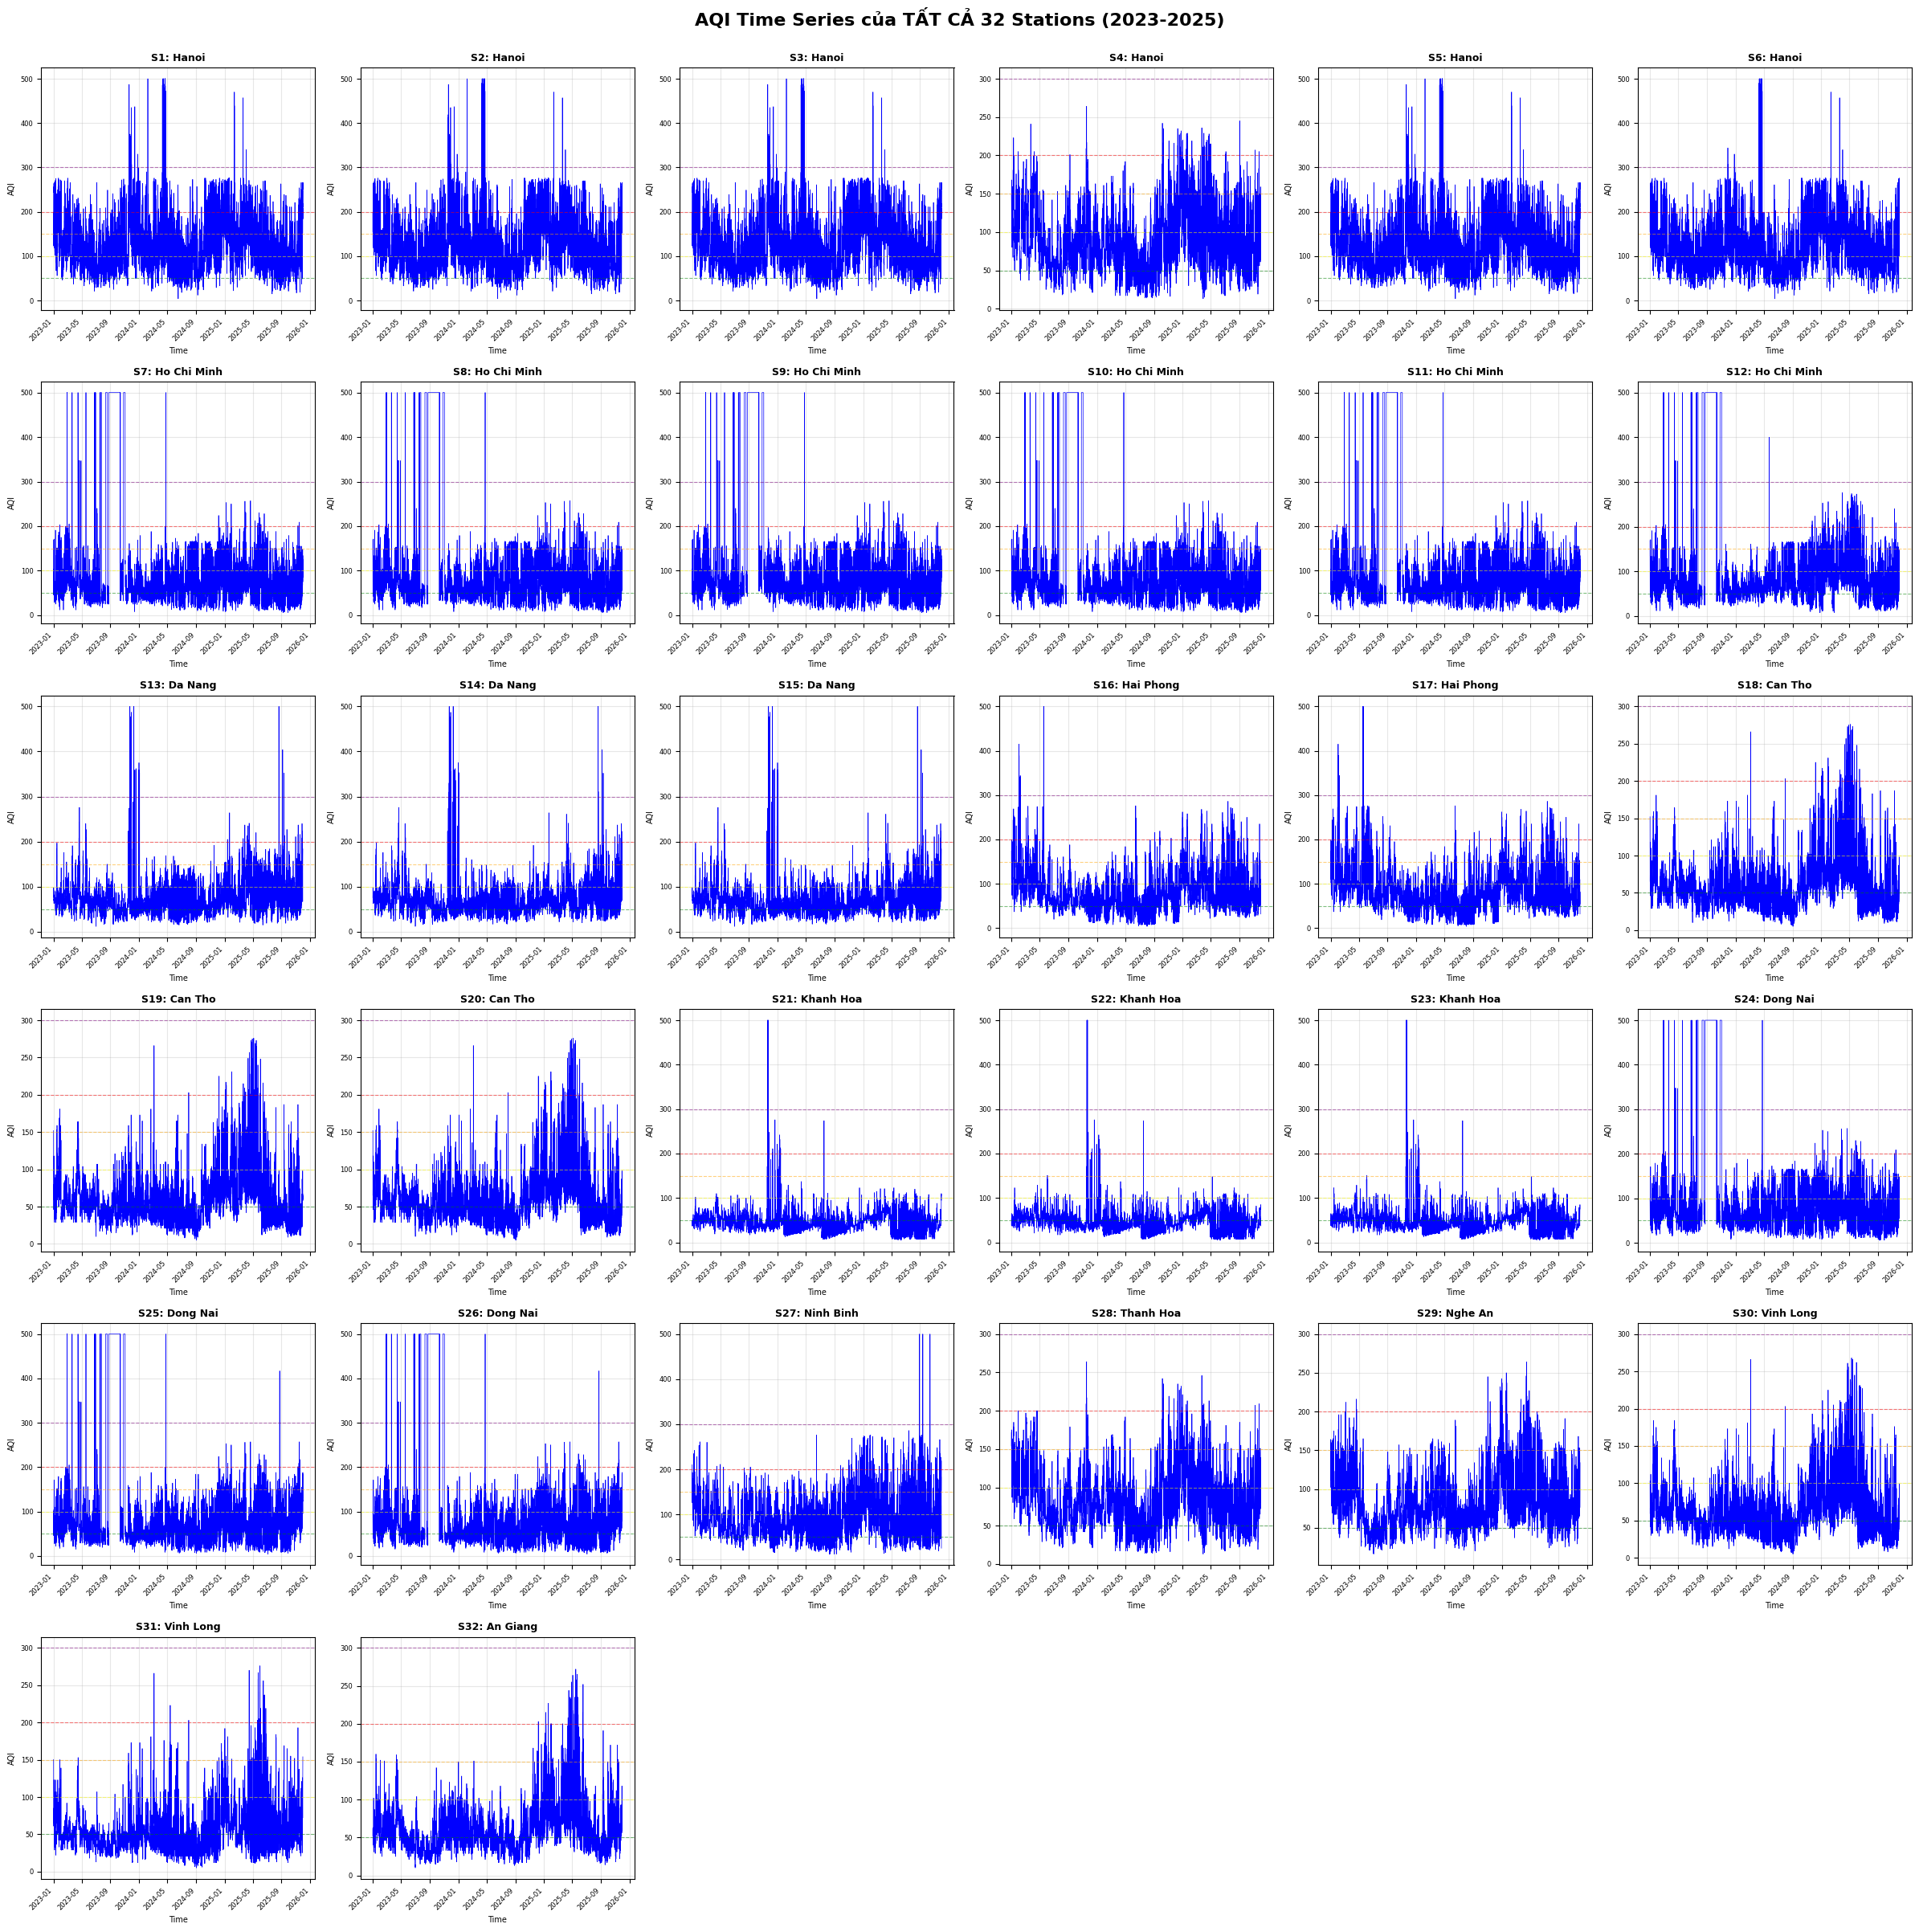


Đã vẽ xong tất cả các biểu đồ!


In [8]:

import warnings
warnings.filterwarnings('ignore')

# Tính số hàng và cột
n_cols = 6
n_rows = (len(station_numbers) + n_cols - 1) // n_cols  # Làm tròn lên

# Tạo figure với subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4*n_rows))
axes = axes.flatten()  # Chuyển thành mảng 1 chiều để dễ truy cập

print("="*100)
print(f"VẼ BIỂU ĐỒ AQI TIME SERIES CHO {len(station_numbers)} STATIONS")
print(f"Layout: {n_rows} hàng x {n_cols} cột")
print("="*100)

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    ax = axes[i]
    
    # Kiểm tra có cột aqi không
    if 'aqi' not in df.columns or df['aqi'].isnull().all():
        ax.text(0.5, 0.5, f'Station {station_num}\nNo AQI data', 
                ha='center', va='center', fontsize=10, transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    city = df['city'].iloc[0] if 'city' in df.columns else 'N/A'
    district = df['district'].iloc[0] if 'district' in df.columns else 'N/A'
    
    # Plot AQI time series
    ax.plot(df['time'], df['aqi'], color='b', linewidth=0.5)
    
    # Add horizontal lines for unhealthy levels
    ax.axhline(y=50, color='green', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=100, color='yellow', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=150, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=200, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(y=300, color='purple', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Set title and labels
    ax.set_title(f'S{station_num}: {city}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Time', fontsize=7)
    ax.set_ylabel('AQI', fontsize=7)
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    # Find and display statistics
    if not df['aqi'].isnull().all():
        highest_aqi_time = df.loc[df['aqi'].idxmax(), 'time']
        highest_aqi_value = df['aqi'].max()
        mean_aqi_value = df['aqi'].mean()
        
        print(f"S{station_num:2d} ({city:15s}): Mean={mean_aqi_value:6.2f}, Max={highest_aqi_value:6.2f} at {highest_aqi_time.date()}")

# Tắt các axes thừa (nếu có)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('AQI Time Series của TẤT CẢ 32 Stations (2023-2025)', 
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("Đã vẽ xong tất cả các biểu đồ!")

# Biểu đồ so sánh AQI của tất cả 32 stations trên cùng một biểu đồ

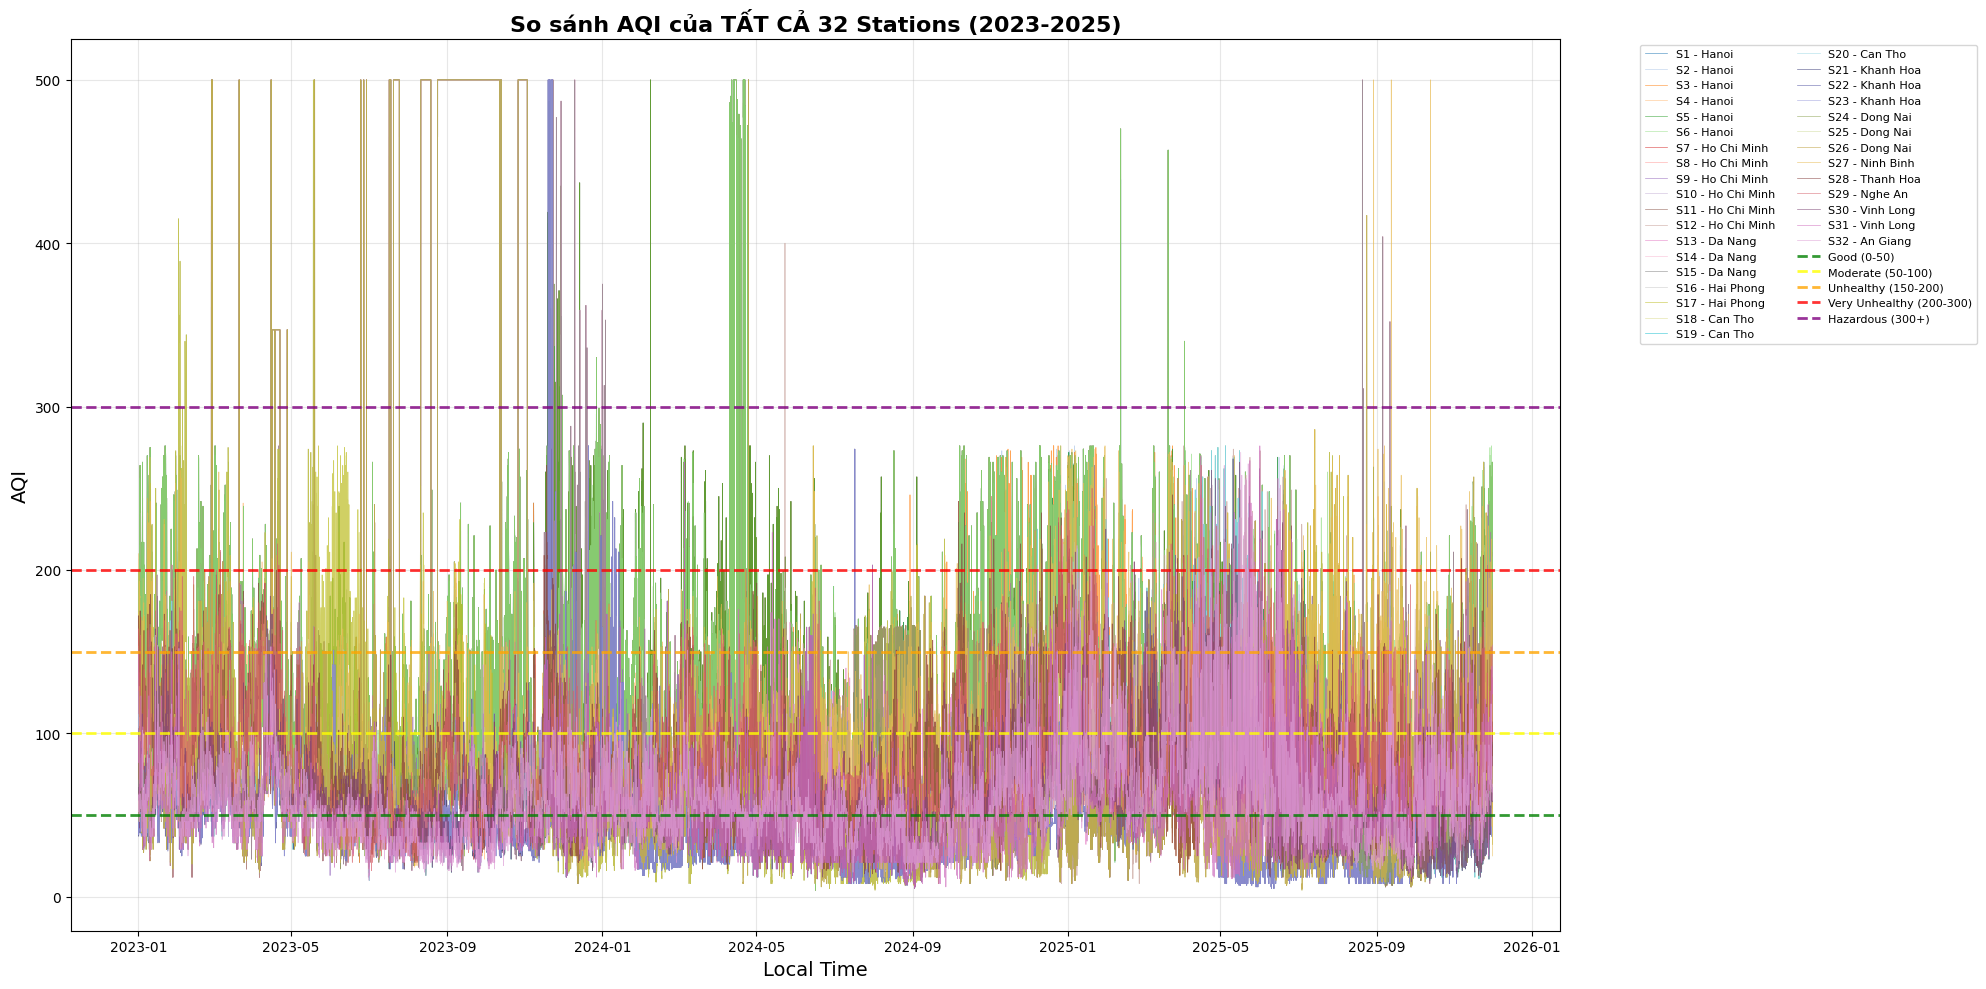

Đã vẽ biểu đồ so sánh AQI của tất cả 32 stations!


In [9]:

plt.figure(figsize=(20, 10))

colors = plt.cm.tab20(np.linspace(0, 1, 20))  # 20 colors
colors2 = plt.cm.tab20b(np.linspace(0, 1, 12))  # 12 more colors
all_colors = np.vstack([colors, colors2])

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'aqi' not in df.columns or df['aqi'].isnull().all():
        continue
    
    city = df['city'].iloc[0] if 'city' in df.columns else 'N/A'
    
    # Plot với màu khác nhau cho mỗi station
    plt.plot(df['time'], df['aqi'], 
             color=all_colors[i % len(all_colors)], 
             linewidth=0.5, 
             alpha=0.7,
             label=f'S{station_num} - {city}')

# Add horizontal lines for unhealthy levels
plt.axhline(y=50, color='green', linestyle='--', label='Good (0-50)', linewidth=2, alpha=0.8)
plt.axhline(y=100, color='yellow', linestyle='--', label='Moderate (50-100)', linewidth=2, alpha=0.8)
plt.axhline(y=150, color='orange', linestyle='--', label='Unhealthy (150-200)', linewidth=2, alpha=0.8)
plt.axhline(y=200, color='red', linestyle='--', label='Very Unhealthy (200-300)', linewidth=2, alpha=0.8)
plt.axhline(y=300, color='purple', linestyle='--', label='Hazardous (300+)', linewidth=2, alpha=0.8)

plt.xlabel('Local Time', fontsize=14)
plt.ylabel('AQI', fontsize=14)
plt.title('So sánh AQI của TẤT CẢ 32 Stations (2023-2025)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Đã vẽ biểu đồ so sánh AQI của tất cả 32 stations!")

SO SÁNH AQI TRUNG BÌNH THEO THÀNH PHỐ


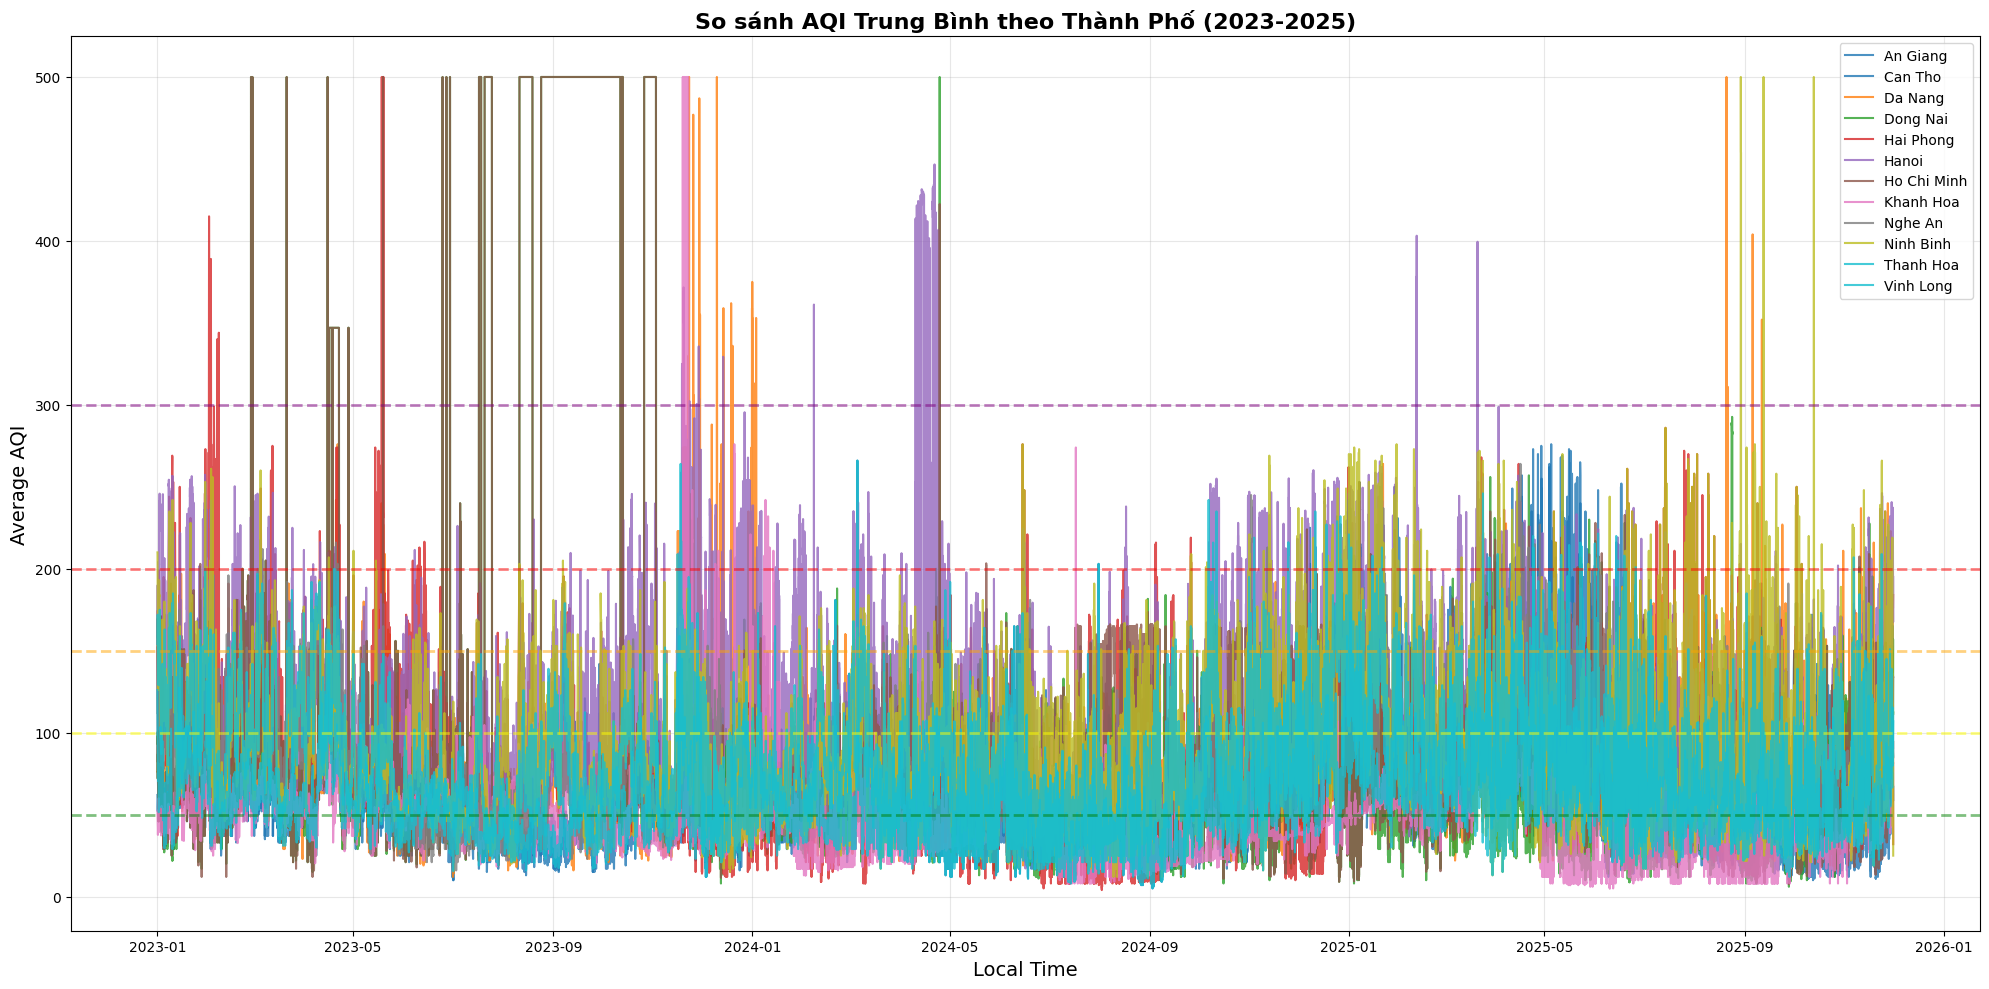


--- Thống kê AQI trung bình theo thành phố ---
       City  Mean AQI  Max AQI  Min AQI  Std AQI
      Hanoi    116.18   446.67    16.17    50.91
Ho Chi Minh    101.58   500.00     7.50   114.23
   Dong Nai     95.39   500.00     6.00   114.68
  Ninh Binh     90.59   500.00    12.00    44.93
  Thanh Hoa     81.44   264.00    13.00    36.11
    Nghe An     81.31   264.00    16.00    33.65
  Hai Phong     81.14   500.00     4.00    44.49
    Da Nang     71.13   500.00    12.00    34.36
   An Giang     61.96   272.00    10.00    30.99
    Can Tho     58.84   276.00     5.00    32.96
  Vinh Long     56.98   266.00     5.00    24.84
  Khanh Hoa     44.81   500.00     5.00    28.71


In [10]:
# Vẽ biểu đồ so sánh AQI trung bình theo thành phố
print("="*80)
print("SO SÁNH AQI TRUNG BÌNH THEO THÀNH PHỐ")
print("="*80)

# Nhóm theo thành phố
city_aqi_data = {}
for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'aqi' not in df.columns or df['aqi'].isnull().all():
        continue
    
    city = df['city'].iloc[0] if 'city' in df.columns else 'N/A'
    
    if city not in city_aqi_data:
        city_aqi_data[city] = []
    
    # Tạo time series với time và aqi
    for _, row in df[['time', 'aqi']].dropna().iterrows():
        city_aqi_data[city].append({'time': row['time'], 'aqi': row['aqi']})

# Tính trung bình AQI theo thời gian cho mỗi thành phố
city_avg_aqi = {}
for city, data in city_aqi_data.items():
    df_city = pd.DataFrame(data)
    # Nhóm theo time và tính mean
    df_city_grouped = df_city.groupby('time')['aqi'].mean().reset_index()
    city_avg_aqi[city] = df_city_grouped

# Vẽ biểu đồ
plt.figure(figsize=(20, 10))

colors_city = plt.cm.tab10(np.linspace(0, 1, len(city_avg_aqi)))

for i, (city, df_city) in enumerate(sorted(city_avg_aqi.items())):
    plt.plot(df_city['time'], df_city['aqi'], 
             color=colors_city[i], 
             linewidth=1.5, 
             alpha=0.8,
             label=city)

# Add horizontal lines for unhealthy levels
plt.axhline(y=50, color='green', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(y=100, color='yellow', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(y=150, color='orange', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(y=200, color='red', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(y=300, color='purple', linestyle='--', linewidth=2, alpha=0.5)

plt.xlabel('Local Time', fontsize=14)
plt.ylabel('Average AQI', fontsize=14)
plt.title('So sánh AQI Trung Bình theo Thành Phố (2023-2025)', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In thống kê
print("\n--- Thống kê AQI trung bình theo thành phố ---")
city_summary = []
for city, df_city in sorted(city_avg_aqi.items()):
    city_summary.append({
        'City': city,
        'Mean AQI': df_city['aqi'].mean(),
        'Max AQI': df_city['aqi'].max(),
        'Min AQI': df_city['aqi'].min(),
        'Std AQI': df_city['aqi'].std()
    })

city_summary_df = pd.DataFrame(city_summary).sort_values('Mean AQI', ascending=False)
print(city_summary_df.round(2).to_string(index=False))

BOXPLOT - PHÂN BỐ AQI CỦA CÁC STATIONS


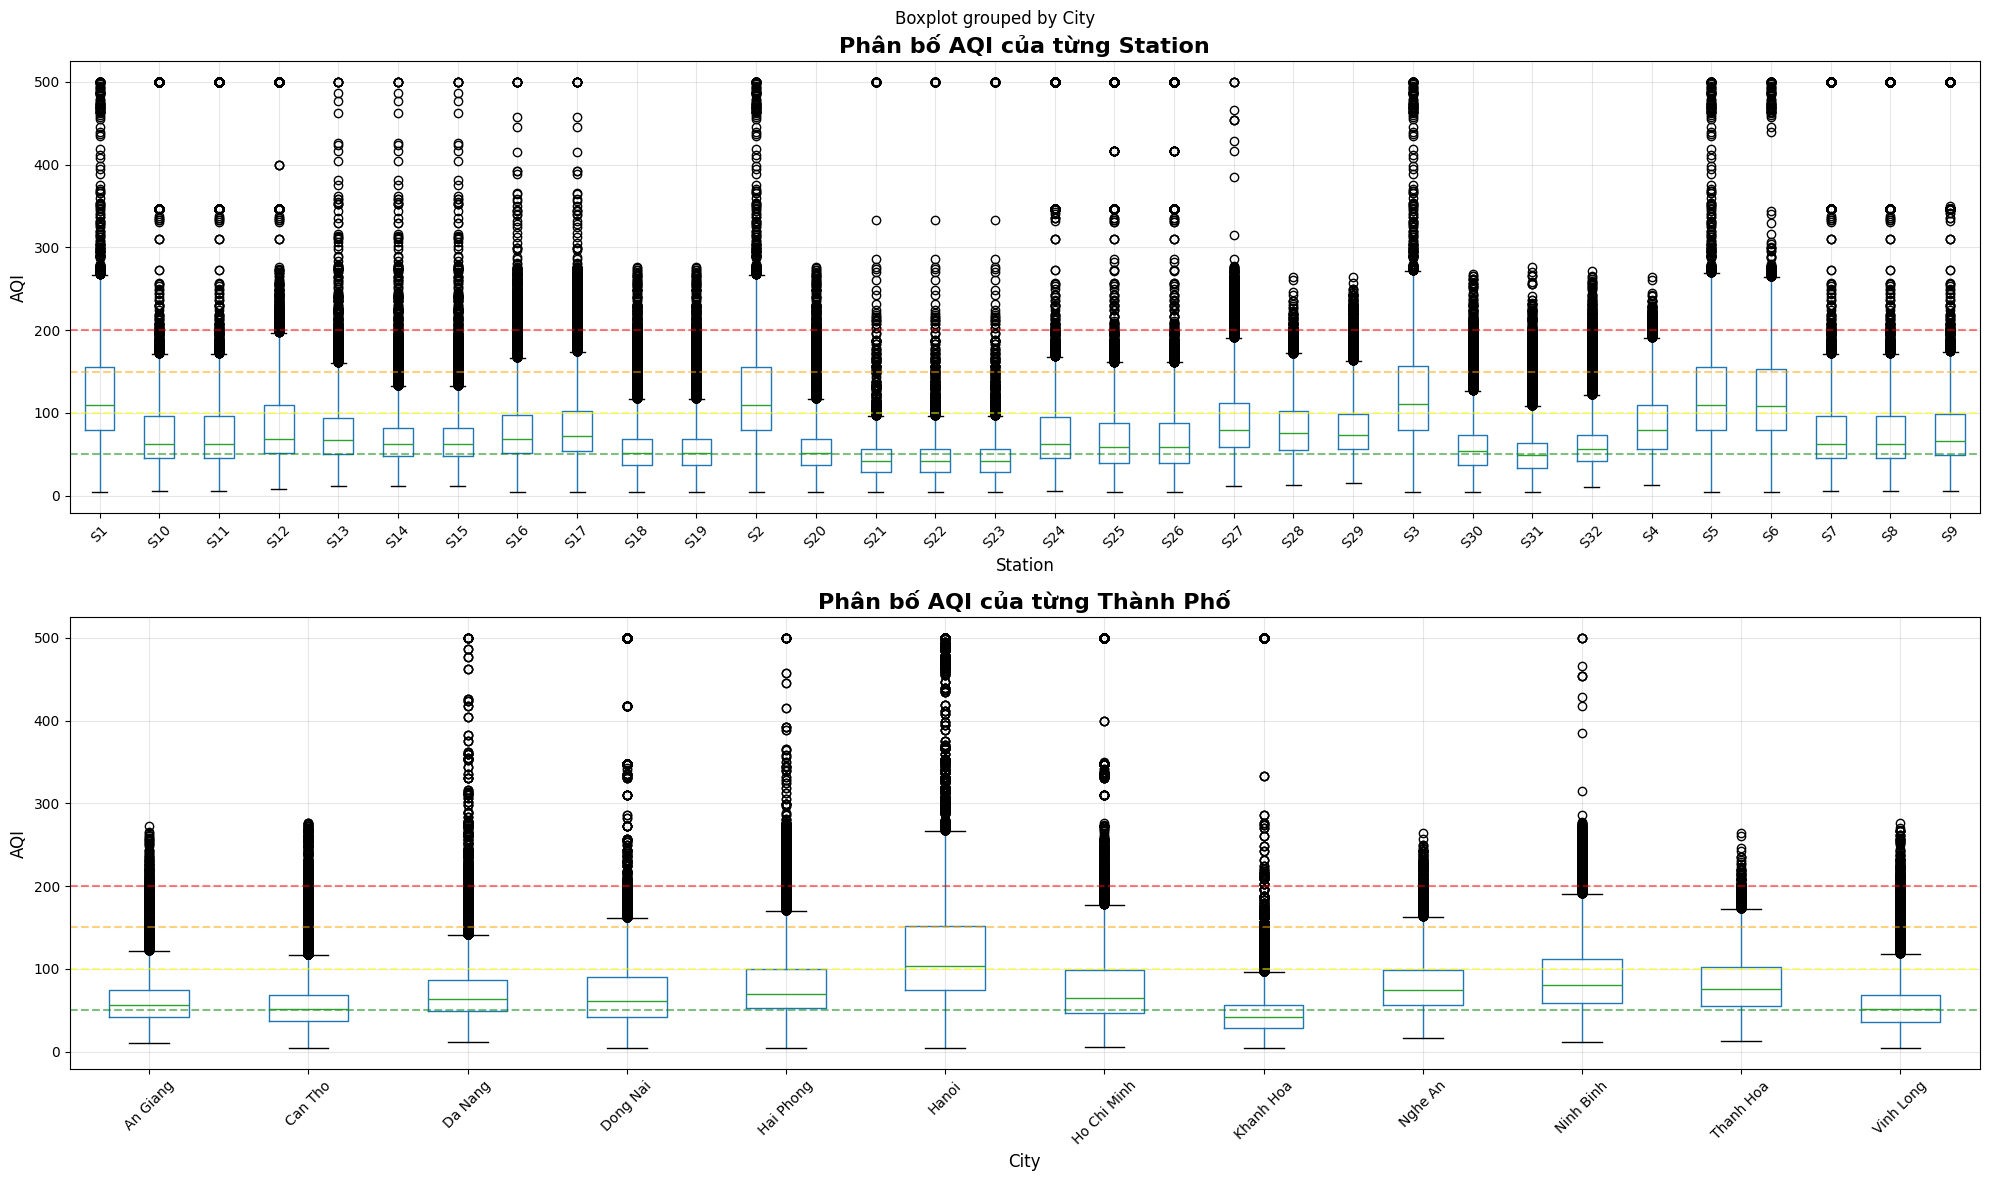


Đã vẽ boxplot cho tất cả các stations và cities!


In [11]:
# Vẽ Boxplot so sánh phân bố AQI của các stations
print("="*80)
print("BOXPLOT - PHÂN BỐ AQI CỦA CÁC STATIONS")
print("="*80)

# Chuẩn bị dữ liệu cho boxplot
aqi_data_for_boxplot = []
for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'aqi' not in df.columns:
        continue
    
    city = df['city'].iloc[0] if 'city' in df.columns else 'N/A'
    
    for aqi_value in df['aqi'].dropna():
        aqi_data_for_boxplot.append({
            'Station': f'S{station_num}',
            'City': city,
            'AQI': aqi_value
        })

df_boxplot = pd.DataFrame(aqi_data_for_boxplot)

# Vẽ boxplot theo station
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

# Boxplot 1: Theo Station
df_boxplot.boxplot(column='AQI', by='Station', ax=axes[0], figsize=(20, 6))
axes[0].set_title('Phân bố AQI của từng Station', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Station', fontsize=12)
axes[0].set_ylabel('AQI', fontsize=12)
axes[0].axhline(y=50, color='green', linestyle='--', alpha=0.5)
axes[0].axhline(y=100, color='yellow', linestyle='--', alpha=0.5)
axes[0].axhline(y=150, color='orange', linestyle='--', alpha=0.5)
axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)
plt.sca(axes[0])
plt.xticks(rotation=45)

# Boxplot 2: Theo City
df_boxplot.boxplot(column='AQI', by='City', ax=axes[1], figsize=(20, 6))
axes[1].set_title('Phân bố AQI của từng Thành Phố', fontsize=16, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12)
axes[1].set_ylabel('AQI', fontsize=12)
axes[1].axhline(y=50, color='green', linestyle='--', alpha=0.5)
axes[1].axhline(y=100, color='yellow', linestyle='--', alpha=0.5)
axes[1].axhline(y=150, color='orange', linestyle='--', alpha=0.5)
axes[1].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nĐã vẽ boxplot cho tất cả các stations và cities!")

# PHÂN TÍCH CHI TIẾT 32 TRẠM - Tương tự Part 2

## Phân tích này sẽ bao gồm:
1. **Phân tích PM2.5 theo giờ trong ngày** - Xác định khung giờ nào có PM2.5 cao nhất
2. **Phân tích PM2.5 theo mùa** - So sánh mức độ ô nhiễm giữa các mùa
3. **Phân tích thời tiết** - Lượng mưa, nhiệt độ, độ ẩm, tốc độ gió
4. **Ảnh hưởng của điều kiện thời tiết lên chất lượng không khí** - Correlation analysis
5. **So sánh giữa các thành phố và khu vực**

## 1. PHÂN TÍCH PM2.5 THEO GIỜ TRONG NGÀY

Phân tích này sẽ tìm ra những giờ nào trong ngày có nồng độ PM2.5 cao nhất trên các trạm

PHÂN TÍCH PM2.5 THEO GIỜ TRONG NGÀY - TẤT CẢ 32 TRẠM
S 1 - Top 5 giờ cao nhất PM2.5: 8h(56.1), 20h(55.4), 21h(55.0), 9h(54.9), 7h(54.0)
S 2 - Top 5 giờ cao nhất PM2.5: 8h(56.2), 20h(55.2), 9h(55.0), 7h(54.9), 21h(54.8)
S 3 - Top 5 giờ cao nhất PM2.5: 21h(57.3), 20h(57.0), 8h(56.7), 9h(55.7), 23h(55.5)
S 4 - Top 5 giờ cao nhất PM2.5: 22h(32.4), 1h(32.2), 7h(31.6), 4h(31.3), 2h(31.1)
S 5 - Top 5 giờ cao nhất PM2.5: 8h(56.0), 20h(55.4), 21h(55.0), 9h(54.8), 7h(53.9)
S 6 - Top 5 giờ cao nhất PM2.5: 8h(51.8), 21h(51.1), 7h(51.0), 20h(51.0), 9h(50.7)
S 7 - Top 5 giờ cao nhất PM2.5: 7h(87.8), 10h(86.7), 19h(86.4), 9h(85.5), 20h(84.6)
S 8 - Top 5 giờ cao nhất PM2.5: 7h(87.8), 10h(86.7), 19h(86.4), 9h(85.5), 20h(84.6)
S 9 - Top 5 giờ cao nhất PM2.5: 7h(88.6), 19h(87.8), 10h(87.2), 9h(86.0), 20h(85.9)
S10 - Top 5 giờ cao nhất PM2.5: 7h(87.8), 10h(86.7), 19h(86.4), 9h(85.5), 20h(84.6)
S11 - Top 5 giờ cao nhất PM2.5: 7h(87.8), 10h(86.7), 19h(86.4), 9h(85.5), 20h(84.6)
S12 - Top 5 giờ cao nhất PM2.

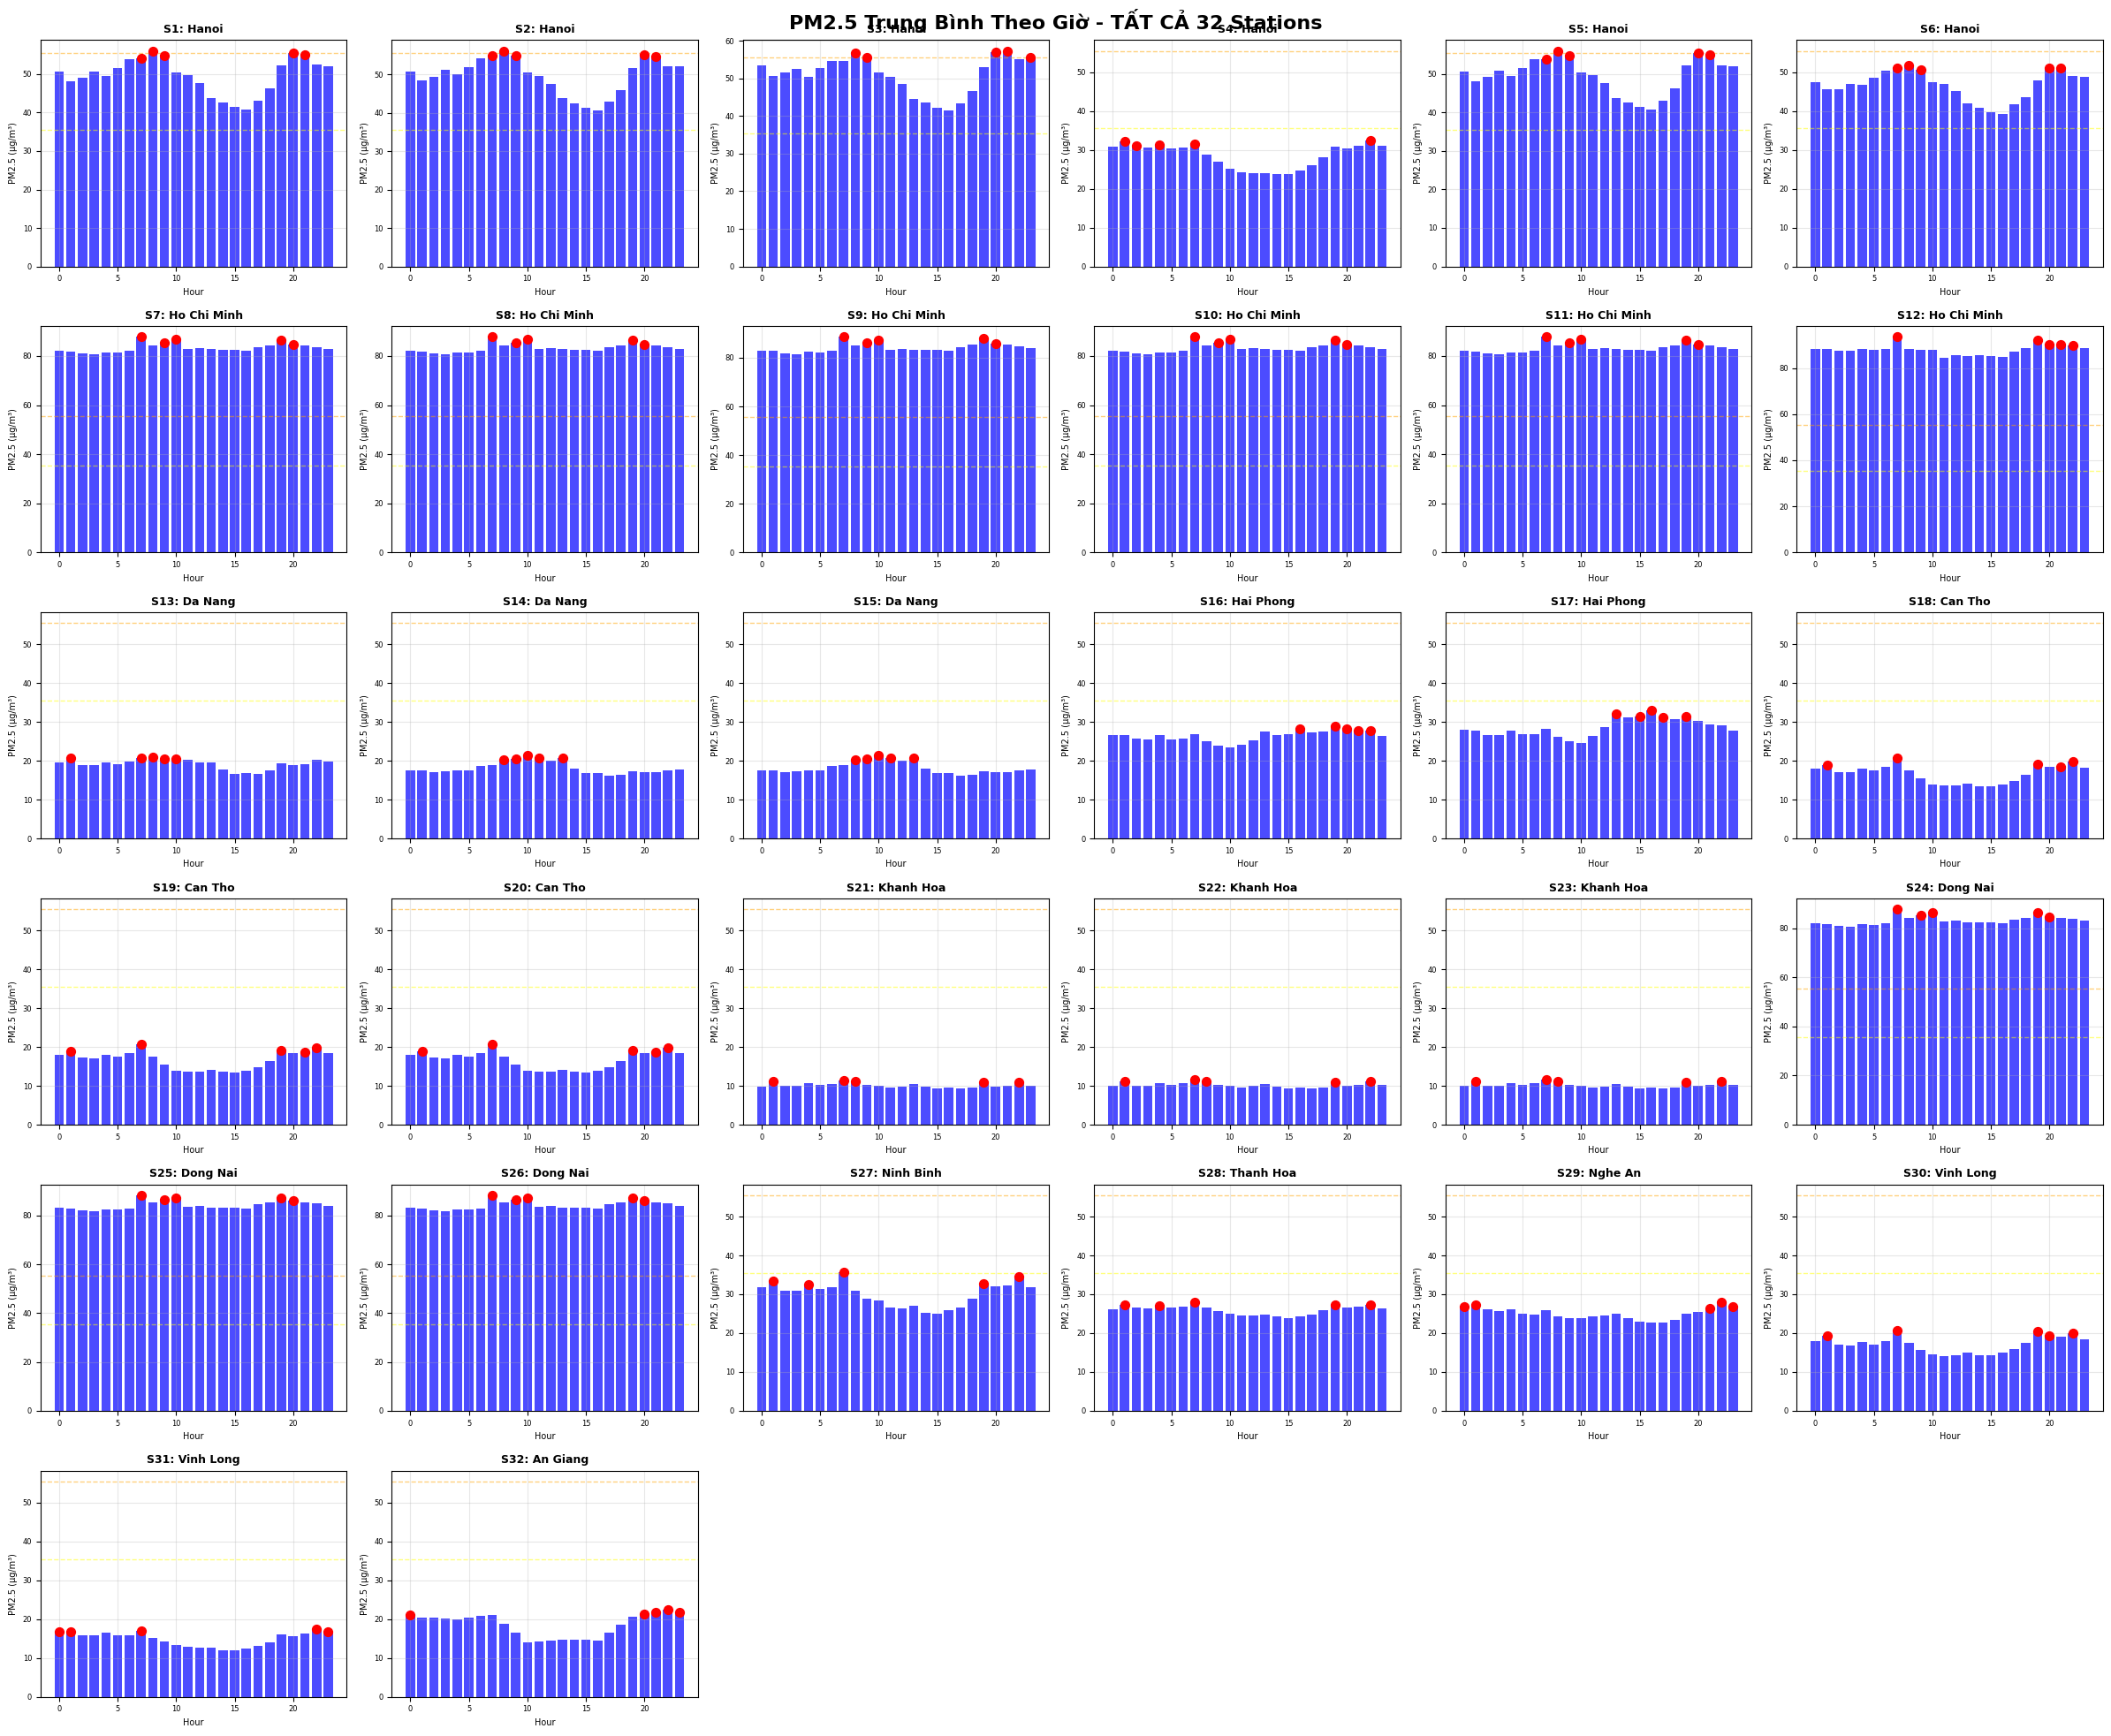


PM2.5 TRUNG BÌNH THEO GIỜ - TỔNG HỢP TẤT CẢ TRẠM


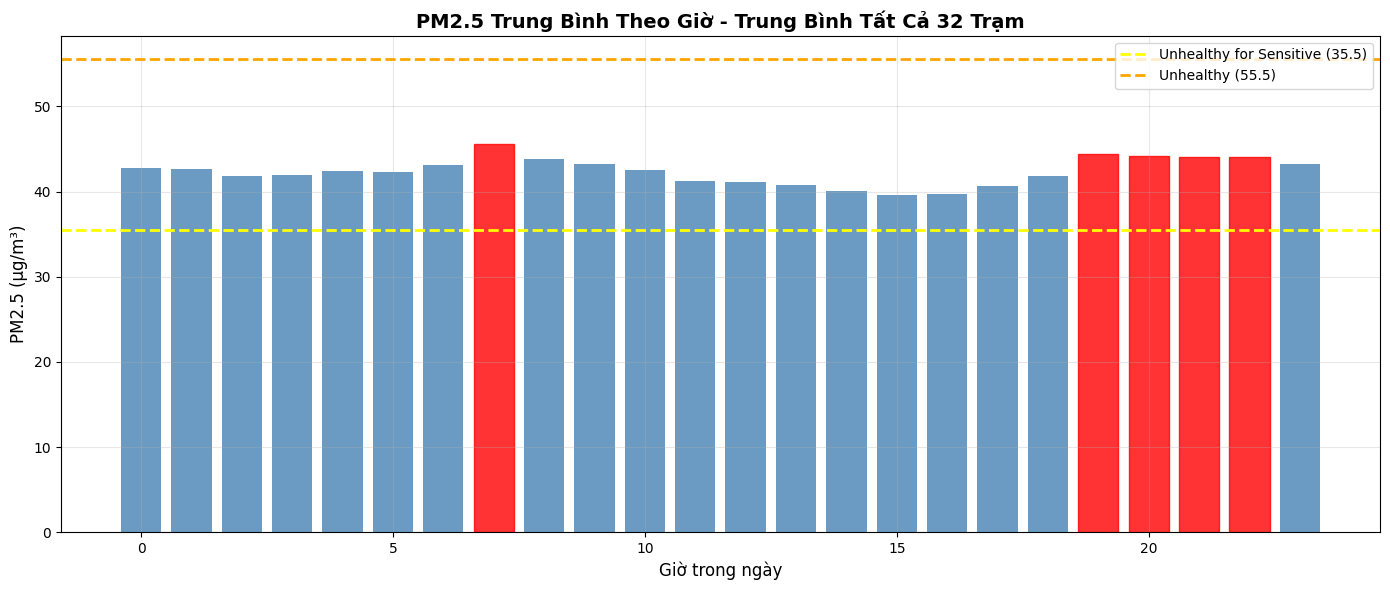


--- Top 5 giờ có PM2.5 cao nhất (trung bình tất cả trạm) ---
Giờ  7:00 - PM2.5: 45.53 μg/m³
Giờ 19:00 - PM2.5: 44.39 μg/m³
Giờ 20:00 - PM2.5: 44.17 μg/m³
Giờ 22:00 - PM2.5: 44.10 μg/m³
Giờ 21:00 - PM2.5: 44.10 μg/m³


In [12]:
print("="*100)
print("PHÂN TÍCH PM2.5 THEO GIỜ TRONG NGÀY - TẤT CẢ 32 TRẠM")
print("="*100)

# Tạo DataFrame để lưu PM2.5 theo giờ cho từng station
hourly_pm25_by_station = {}

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'pm25' not in df.columns or 'time' not in df.columns:
        continue
    
    # Trích xuất giờ từ timestamp
    df_temp = df.copy()
    df_temp['hour'] = df_temp['time'].dt.hour
    
    # Tính PM2.5 trung bình theo giờ
    hourly_pm25 = df_temp.groupby('hour')['pm25'].mean()
    hourly_pm25_by_station[station_num] = hourly_pm25

# Vẽ biểu đồ cho TẤT CẢ các stations
fig, axes = plt.subplots(6, 6, figsize=(24, 20))
axes = axes.flatten()

for idx, station_num in enumerate(sorted(hourly_pm25_by_station.keys())):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    hourly_data = hourly_pm25_by_station[station_num]
    
    # Tìm 5 giờ cao nhất
    highest_hours = hourly_data.nlargest(5)
    
    # Vẽ bar chart
    ax.bar(hourly_data.index, hourly_data.values, color='blue', alpha=0.7)
    ax.scatter(highest_hours.index, highest_hours.values, color='red', s=50, zorder=5)
    
    # Thêm threshold lines
    ax.axhline(y=35.5, color='yellow', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=55.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    
    # Labels
    city = station_dataframes[station_numbers.index(station_num)]['city'].iloc[0]
    ax.set_title(f'S{station_num}: {city}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Hour', fontsize=7)
    ax.set_ylabel('PM2.5 (μg/m³)', fontsize=7)
    ax.tick_params(axis='both', labelsize=6)
    ax.grid(True, alpha=0.3)
    
    print(f"S{station_num:2d} - Top 5 giờ cao nhất PM2.5: {', '.join([f'{h}h({v:.1f})' for h, v in highest_hours.items()])}")

# Tắt axes thừa
for idx in range(len(hourly_pm25_by_station), len(axes)):
    axes[idx].axis('off')

plt.suptitle('PM2.5 Trung Bình Theo Giờ - TẤT CẢ 32 Stations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Tính PM2.5 trung bình theo giờ cho TẤT CẢ các trạm
print("\n" + "="*100)
print("PM2.5 TRUNG BÌNH THEO GIỜ - TỔNG HỢP TẤT CẢ TRẠM")
print("="*100)

all_hourly_data = pd.DataFrame(hourly_pm25_by_station).T
overall_hourly_mean = all_hourly_data.mean()

plt.figure(figsize=(14, 6))
bars = plt.bar(overall_hourly_mean.index, overall_hourly_mean.values, color='steelblue', alpha=0.8)

# Highlight top 5 hours
top5_hours = overall_hourly_mean.nlargest(5)
for hour in top5_hours.index:
    bars[hour].set_color('red')

plt.axhline(y=35.5, color='yellow', linestyle='--', linewidth=2, label='Unhealthy for Sensitive (35.5)')
plt.axhline(y=55.5, color='orange', linestyle='--', linewidth=2, label='Unhealthy (55.5)')

plt.title('PM2.5 Trung Bình Theo Giờ - Trung Bình Tất Cả 32 Trạm', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=12)
plt.ylabel('PM2.5 (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Top 5 giờ có PM2.5 cao nhất (trung bình tất cả trạm) ---")
for hour, value in top5_hours.items():
    print(f"Giờ {hour:2d}:00 - PM2.5: {value:.2f} μg/m³")

## 2. PHÂN TÍCH PM2.5 THEO MÙA

Phân tích nồng độ PM2.5 trung bình theo từng mùa (Xuân, Hạ, Thu, Đông) cho tất cả các trạm

PHÂN TÍCH PM2.5 THEO MÙA - TẤT CẢ 32 TRẠM
S 1 - Mùa có PM2.5 cao nhất: Đông (Winter) (79.39 μg/m³)
S 2 - Mùa có PM2.5 cao nhất: Đông (Winter) (79.78 μg/m³)
S 3 - Mùa có PM2.5 cao nhất: Đông (Winter) (83.32 μg/m³)
S 4 - Mùa có PM2.5 cao nhất: Đông (Winter) (36.92 μg/m³)
S 5 - Mùa có PM2.5 cao nhất: Đông (Winter) (79.06 μg/m³)
S 6 - Mùa có PM2.5 cao nhất: Đông (Winter) (71.14 μg/m³)
S 7 - Mùa có PM2.5 cao nhất: Thu (Autumn) (233.54 μg/m³)
S 8 - Mùa có PM2.5 cao nhất: Thu (Autumn) (233.54 μg/m³)
S 9 - Mùa có PM2.5 cao nhất: Thu (Autumn) (234.46 μg/m³)
S10 - Mùa có PM2.5 cao nhất: Thu (Autumn) (233.54 μg/m³)
S11 - Mùa có PM2.5 cao nhất: Thu (Autumn) (233.54 μg/m³)
S12 - Mùa có PM2.5 cao nhất: Thu (Autumn) (234.47 μg/m³)
S13 - Mùa có PM2.5 cao nhất: Đông (Winter) (24.83 μg/m³)
S14 - Mùa có PM2.5 cao nhất: Đông (Winter) (23.69 μg/m³)
S15 - Mùa có PM2.5 cao nhất: Đông (Winter) (23.69 μg/m³)
S16 - Mùa có PM2.5 cao nhất: Xuân (Spring) (34.48 μg/m³)
S17 - Mùa có PM2.5 cao nhất: Xuân (Spring) (34

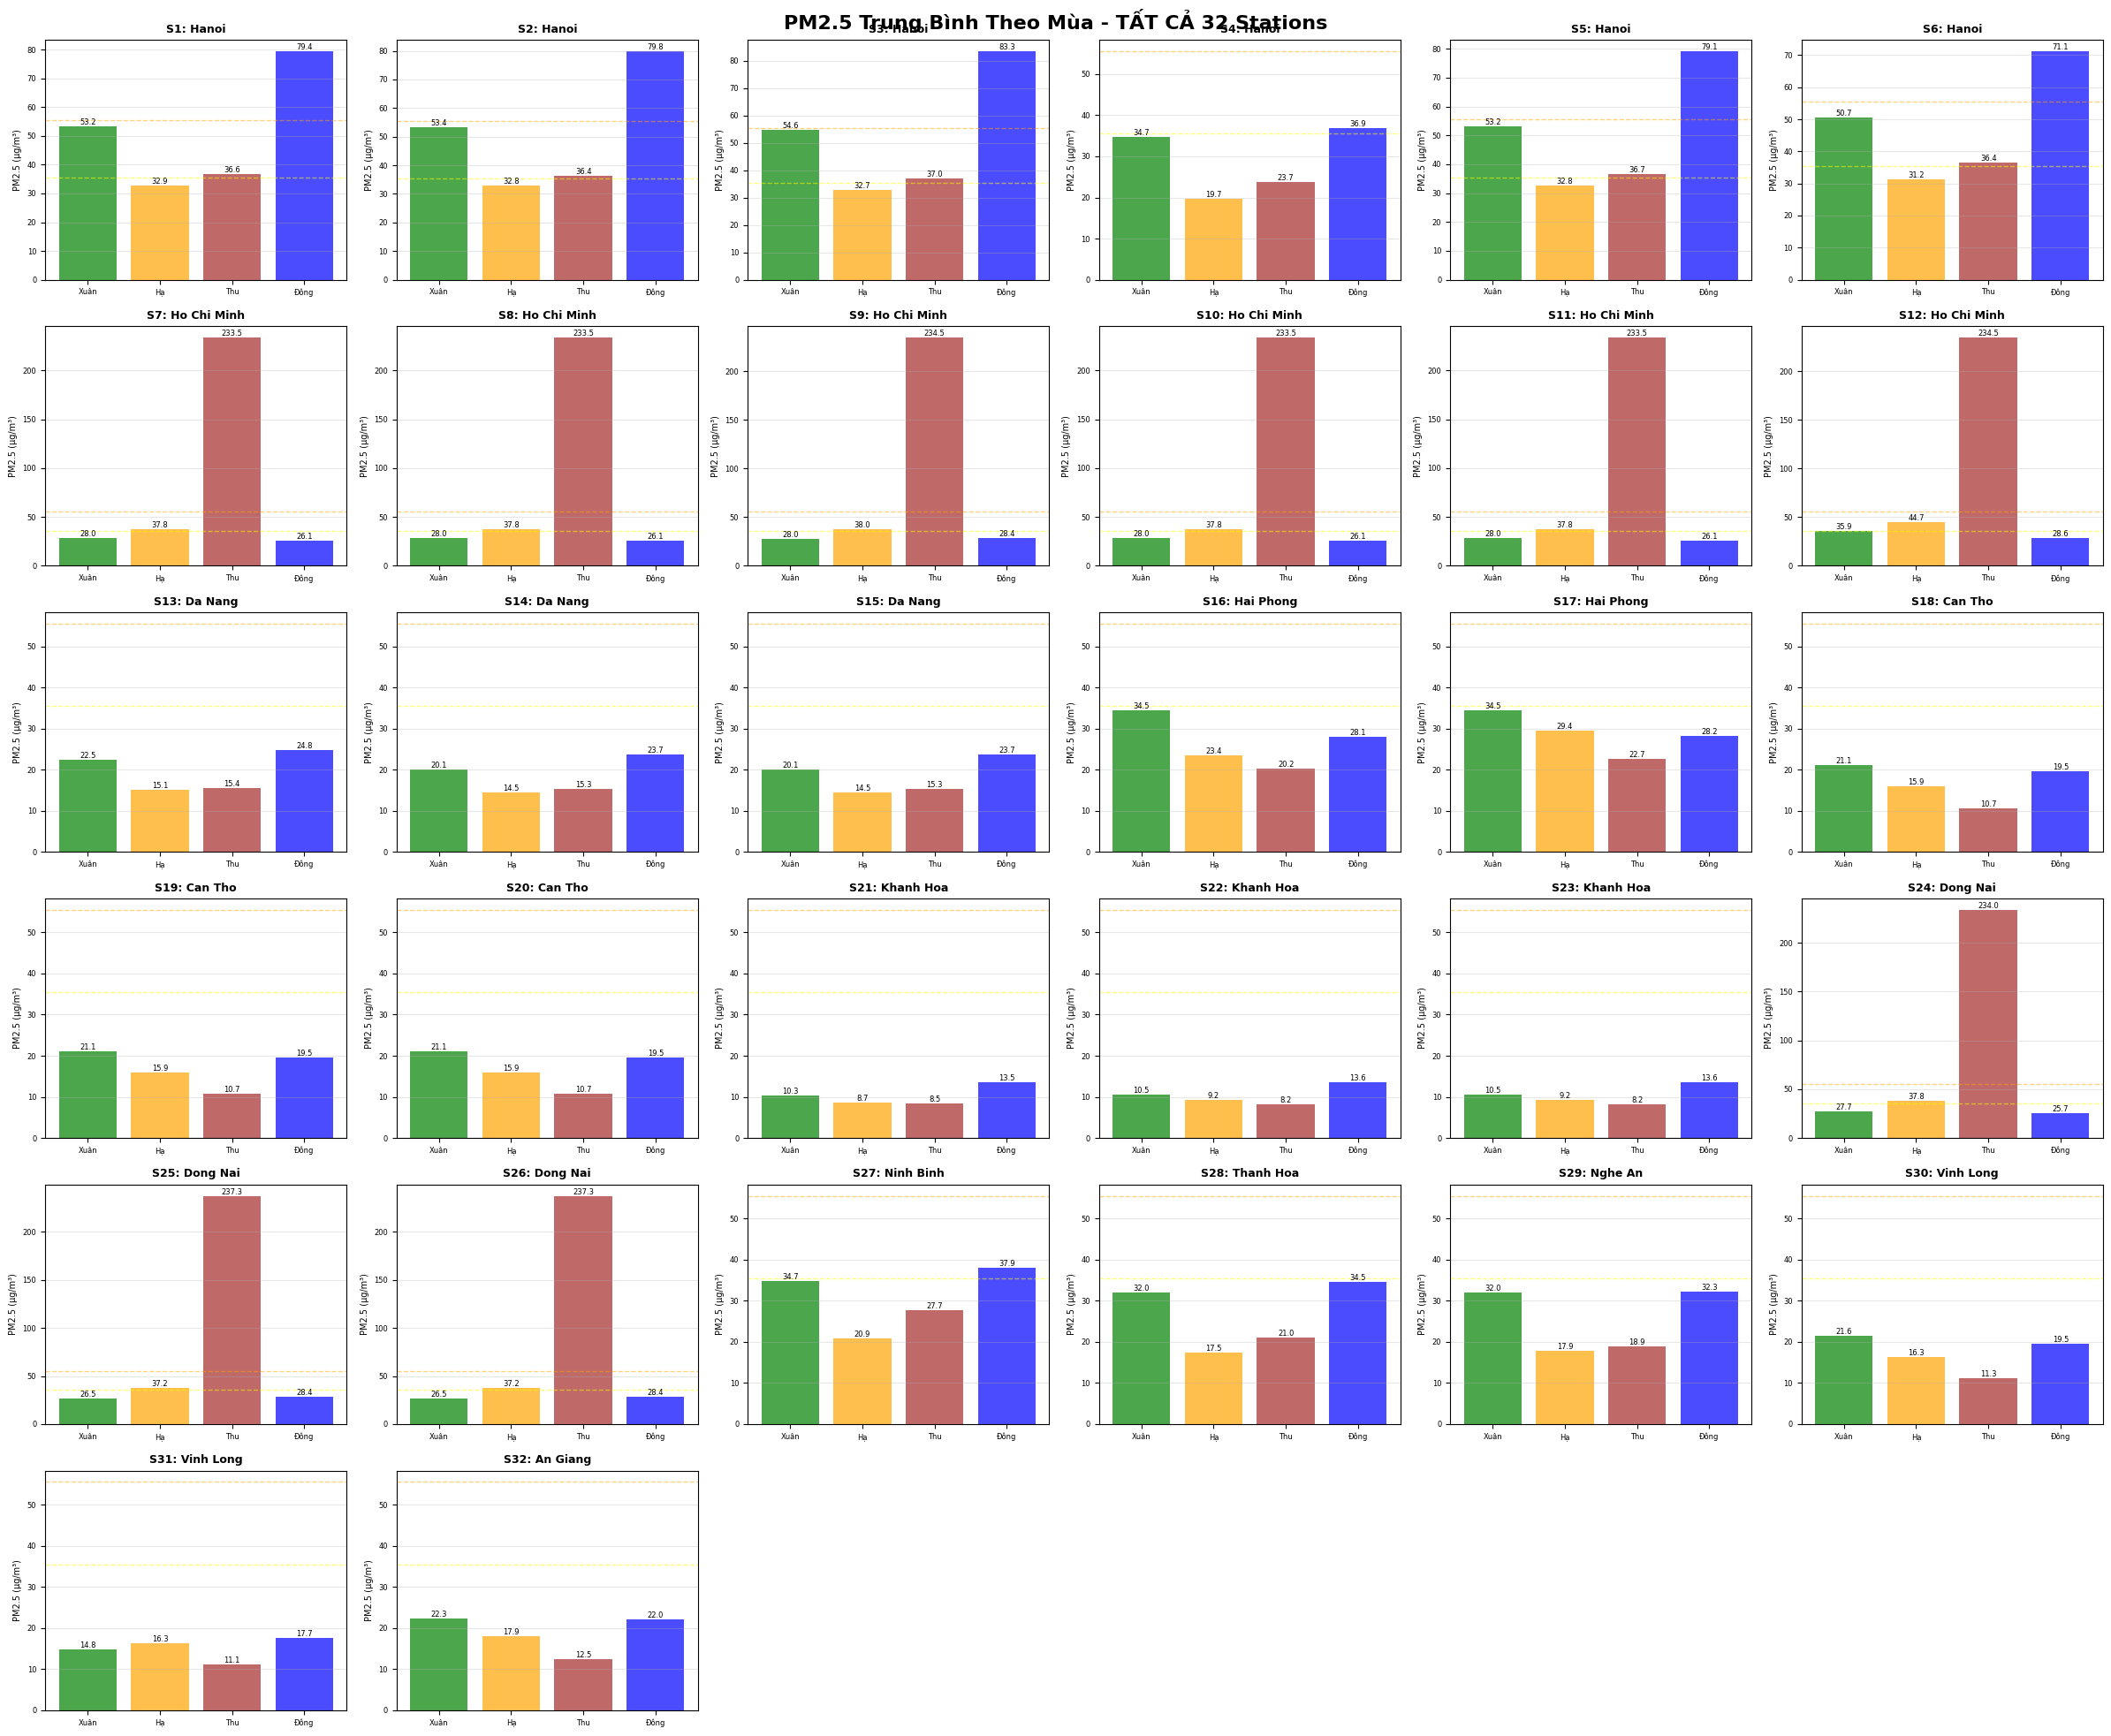


PM2.5 TRUNG BÌNH THEO MÙA - TỔNG HỢP TẤT CẢ TRẠM


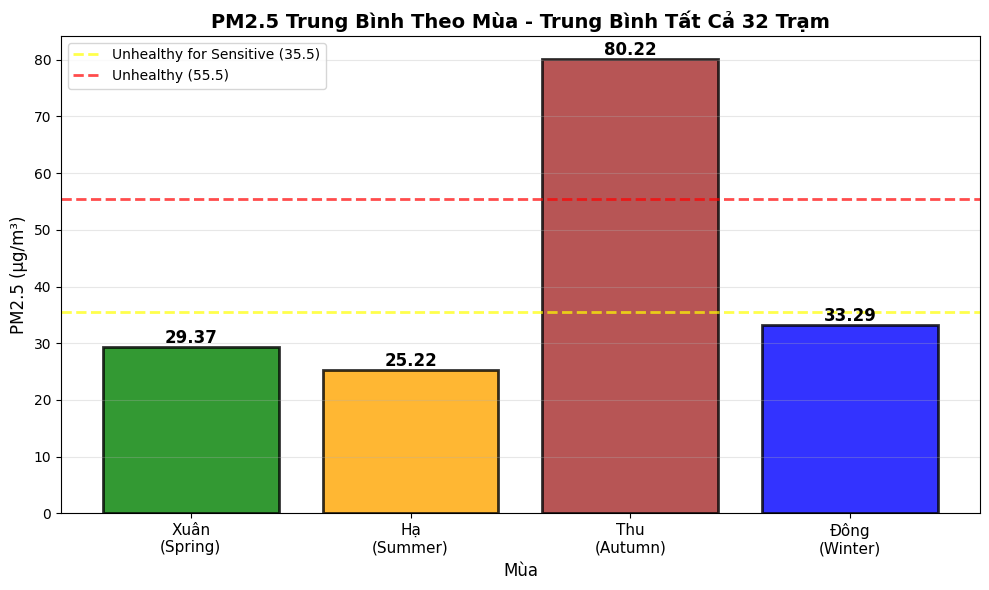


--- PM2.5 trung bình theo mùa (tất cả trạm) ---
Xuân (Spring)       : 29.37 μg/m³
Hạ (Summer)         : 25.22 μg/m³
Thu (Autumn)        : 80.22 μg/m³
Đông (Winter)       : 33.29 μg/m³


In [13]:
print("="*100)
print("PHÂN TÍCH PM2.5 THEO MÙA - TẤT CẢ 32 TRẠM")
print("="*100)

# Định nghĩa các mùa (theo khí hậu Việt Nam / Bắc bộ)
seasons = {
    'Xuân (Spring)': [2, 3, 4],
    'Hạ (Summer)': [5, 6, 7],
    'Thu (Autumn)': [8, 9, 10],
    'Đông (Winter)': [11, 12, 1]
}

# Tính PM2.5 theo mùa cho từng station
seasonal_pm25_by_station = {}

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'pm25' not in df.columns or 'time' not in df.columns:
        continue
    
    df_temp = df.copy()
    df_temp['month'] = df_temp['time'].dt.month
    
    seasonal_data = {}
    for season, months in seasons.items():
        seasonal_data[season] = df_temp.loc[df_temp['month'].isin(months), 'pm25'].mean()
    
    seasonal_pm25_by_station[station_num] = seasonal_data

# Vẽ biểu đồ cho TẤT CẢ các stations
fig, axes = plt.subplots(6, 6, figsize=(24, 20))
axes = axes.flatten()

for idx, station_num in enumerate(sorted(seasonal_pm25_by_station.keys())):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    seasonal_data = seasonal_pm25_by_station[station_num]
    
    # Vẽ bar chart
    bars = ax.bar(range(len(seasonal_data)), list(seasonal_data.values()), 
                   color=['green', 'orange', 'brown', 'blue'], alpha=0.7)
    ax.set_xticks(range(len(seasonal_data)))
    ax.set_xticklabels(['Xuân', 'Hạ', 'Thu', 'Đông'], fontsize=7)
    
    # Thêm threshold lines
    ax.axhline(y=35.5, color='yellow', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=55.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
    
    # Annotate values
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}', ha='center', va='bottom', fontsize=6)
    
    # Labels
    city = station_dataframes[station_numbers.index(station_num)]['city'].iloc[0]
    ax.set_title(f'S{station_num}: {city}', fontsize=9, fontweight='bold')
    ax.set_ylabel('PM2.5 (μg/m³)', fontsize=7)
    ax.tick_params(axis='both', labelsize=6)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Print summary
    max_season = max(seasonal_data, key=seasonal_data.get)
    print(f"S{station_num:2d} - Mùa có PM2.5 cao nhất: {max_season} ({seasonal_data[max_season]:.2f} μg/m³)")

# Tắt axes thừa
for idx in range(len(seasonal_pm25_by_station), len(axes)):
    axes[idx].axis('off')

plt.suptitle('PM2.5 Trung Bình Theo Mùa - TẤT CẢ 32 Stations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Tính PM2.5 trung bình theo mùa cho TẤT CẢ các trạm
print("\n" + "="*100)
print("PM2.5 TRUNG BÌNH THEO MÙA - TỔNG HỢP TẤT CẢ TRẠM")
print("="*100)

all_seasonal_data = pd.DataFrame(seasonal_pm25_by_station).T
overall_seasonal_mean = all_seasonal_data.mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(overall_seasonal_mean)), overall_seasonal_mean.values, 
               color=['green', 'orange', 'brown', 'blue'], alpha=0.8, edgecolor='black', linewidth=2)
plt.xticks(range(len(overall_seasonal_mean)), ['Xuân\n(Spring)', 'Hạ\n(Summer)', 'Thu\n(Autumn)', 'Đông\n(Winter)'], fontsize=11)

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.axhline(y=35.5, color='yellow', linestyle='--', linewidth=2, label='Unhealthy for Sensitive (35.5)', alpha=0.7)
plt.axhline(y=55.5, color='red', linestyle='--', linewidth=2, label='Unhealthy (55.5)', alpha=0.7)

plt.title('PM2.5 Trung Bình Theo Mùa - Trung Bình Tất Cả 32 Trạm', fontsize=14, fontweight='bold')
plt.ylabel('PM2.5 (μg/m³)', fontsize=12)
plt.xlabel('Mùa', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n--- PM2.5 trung bình theo mùa (tất cả trạm) ---")
for season, value in overall_seasonal_mean.items():
    print(f"{season:20s}: {value:.2f} μg/m³")

## 3. PHÂN TÍCH LƯỢNG MƯA (PRECIPITATION)

Phân tích lượng mưa theo mùa và tổng lượng mưa tại các trạm

PHÂN TÍCH LƯỢNG MƯA - TẤT CẢ 32 TRẠM

--- Tổng lượng mưa năm tại các trạm ---


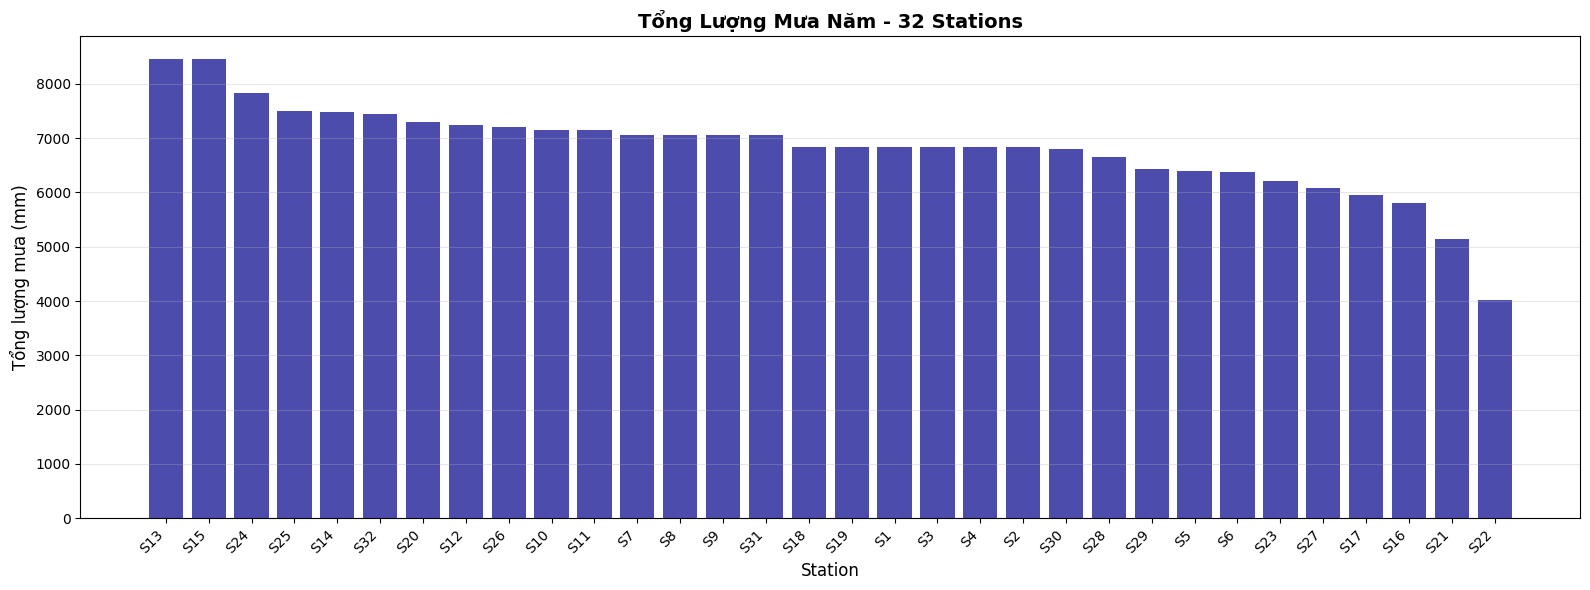


Top 10 trạm có lượng mưa cao nhất:
 1. S13 (Da Nang        ):  8454.40 mm
 2. S15 (Da Nang        ):  8454.40 mm
 3. S24 (Dong Nai       ):  7836.50 mm
 4. S25 (Dong Nai       ):  7503.00 mm
 5. S14 (Da Nang        ):  7489.20 mm
 6. S32 (An Giang       ):  7451.40 mm
 7. S20 (Can Tho        ):  7292.60 mm
 8. S12 (Ho Chi Minh    ):  7242.10 mm
 9. S26 (Dong Nai       ):  7213.20 mm
10. S10 (Ho Chi Minh    ):  7147.40 mm

Top 10 trạm có lượng mưa thấp nhất:
 1. S28 (Thanh Hoa      ):  6647.90 mm
 2. S29 (Nghe An        ):  6426.60 mm
 3. S 5 (Hanoi          ):  6401.10 mm
 4. S 6 (Hanoi          ):  6375.50 mm
 5. S23 (Khanh Hoa      ):  6218.30 mm
 6. S27 (Ninh Binh      ):  6090.20 mm
 7. S17 (Hai Phong      ):  5954.60 mm
 8. S16 (Hai Phong      ):  5806.70 mm
 9. S21 (Khanh Hoa      ):  5141.30 mm
10. S22 (Khanh Hoa      ):  4018.40 mm

LƯỢNG MƯA THEO MÙA - TỔNG HỢP


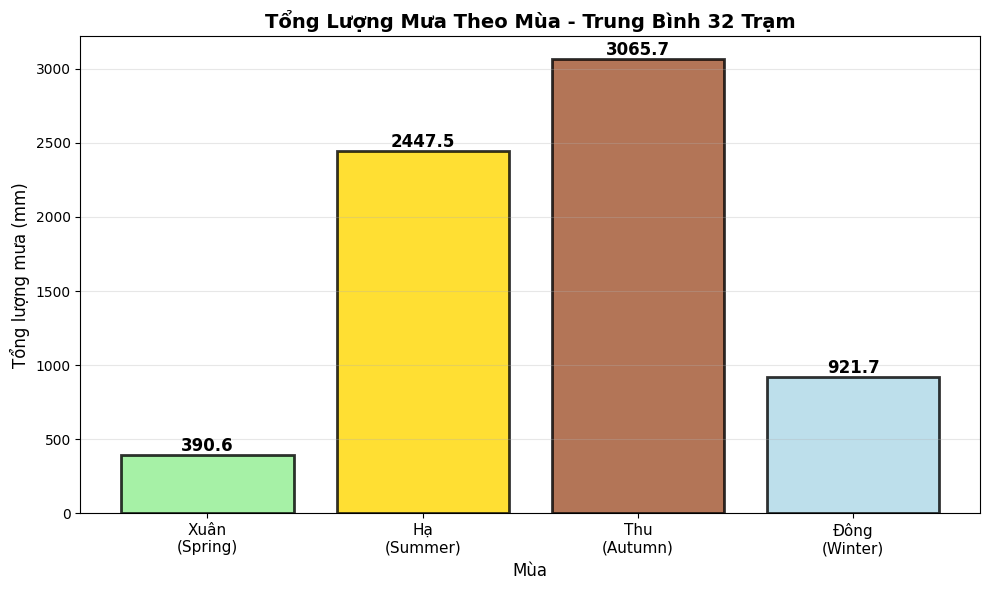


--- Tổng lượng mưa theo mùa (trung bình tất cả trạm) ---
Xuân (Spring)       : 390.58 mm
Hạ (Summer)         : 2447.49 mm
Thu (Autumn)        : 3065.65 mm
Đông (Winter)       : 921.71 mm


In [14]:
print("="*100)
print("PHÂN TÍCH LƯỢNG MƯA - TẤT CẢ 32 TRẠM")
print("="*100)

# Tính tổng lượng mưa theo mùa cho từng station
seasonal_precip_by_station = {}
annual_precip_by_station = {}

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'precipitation' not in df.columns or 'time' not in df.columns:
        continue
    
    df_temp = df.copy()
    df_temp['month'] = df_temp['time'].dt.month
    
    # Tổng lượng mưa năm
    annual_precip_by_station[station_num] = df_temp['precipitation'].sum()
    
    # Lượng mưa theo mùa
    seasonal_data = {}
    for season, months in seasons.items():
        seasonal_data[season] = df_temp.loc[df_temp['month'].isin(months), 'precipitation'].sum()
    
    seasonal_precip_by_station[station_num] = seasonal_data

# Vẽ biểu đồ so sánh tổng lượng mưa năm
print("\n--- Tổng lượng mưa năm tại các trạm ---")
sorted_stations = sorted(annual_precip_by_station.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(16, 6))
stations_list = [f'S{s[0]}' for s in sorted_stations]
precip_values = [s[1] for s in sorted_stations]

bars = plt.bar(stations_list, precip_values, color='darkblue', alpha=0.7)
plt.title('Tổng Lượng Mưa Năm - 32 Stations', fontsize=14, fontweight='bold')
plt.xlabel('Station', fontsize=12)
plt.ylabel('Tổng lượng mưa (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# In top 10 và bottom 10
print(f"\nTop 10 trạm có lượng mưa cao nhất:")
for i, (station, precip) in enumerate(sorted_stations[:10], 1):
    city = station_dataframes[station_numbers.index(station)]['city'].iloc[0]
    print(f"{i:2d}. S{station:2d} ({city:15s}): {precip:8.2f} mm")

print(f"\nTop 10 trạm có lượng mưa thấp nhất:")
for i, (station, precip) in enumerate(sorted_stations[-10:], 1):
    city = station_dataframes[station_numbers.index(station)]['city'].iloc[0]
    print(f"{i:2d}. S{station:2d} ({city:15s}): {precip:8.2f} mm")

# Vẽ biểu đồ lượng mưa theo mùa
print("\n" + "="*100)
print("LƯỢNG MƯA THEO MÙA - TỔNG HỢP")
print("="*100)

all_seasonal_precip = pd.DataFrame(seasonal_precip_by_station).T
overall_seasonal_precip = all_seasonal_precip.mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(overall_seasonal_precip)), overall_seasonal_precip.values, 
               color=['lightgreen', 'gold', 'sienna', 'lightblue'], alpha=0.8, edgecolor='black', linewidth=2)
plt.xticks(range(len(overall_seasonal_precip)), ['Xuân\n(Spring)', 'Hạ\n(Summer)', 'Thu\n(Autumn)', 'Đông\n(Winter)'], fontsize=11)

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Tổng Lượng Mưa Theo Mùa - Trung Bình 32 Trạm', fontsize=14, fontweight='bold')
plt.ylabel('Tổng lượng mưa (mm)', fontsize=12)
plt.xlabel('Mùa', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n--- Tổng lượng mưa theo mùa (trung bình tất cả trạm) ---")
for season, value in overall_seasonal_precip.items():
    print(f"{season:20s}: {value:.2f} mm")

## 4. PHÂN TÍCH NHIỆT ĐỘ, ĐỘ ẨM, TỐC ĐỘ GIÓ THEO MÙA

PHÂN TÍCH NHIỆT ĐỘ, ĐỘ ẨM, TỐC ĐỘ GIÓ THEO MÙA

--- Nhiệt độ (°C) trung bình theo mùa ---
Xuân (Spring)       : 25.66
Hạ (Summer)         : 28.32
Thu (Autumn)        : 27.14
Đông (Winter)       : 23.50

--- Độ ẩm (%) trung bình theo mùa ---
Xuân (Spring)       : 76.10
Hạ (Summer)         : 82.04
Thu (Autumn)        : 84.05
Đông (Winter)       : 77.76

--- Tốc độ gió (m/s) trung bình theo mùa ---
Xuân (Spring)       : 2.70
Hạ (Summer)         : 2.36
Thu (Autumn)        : 2.20
Đông (Winter)       : 2.34


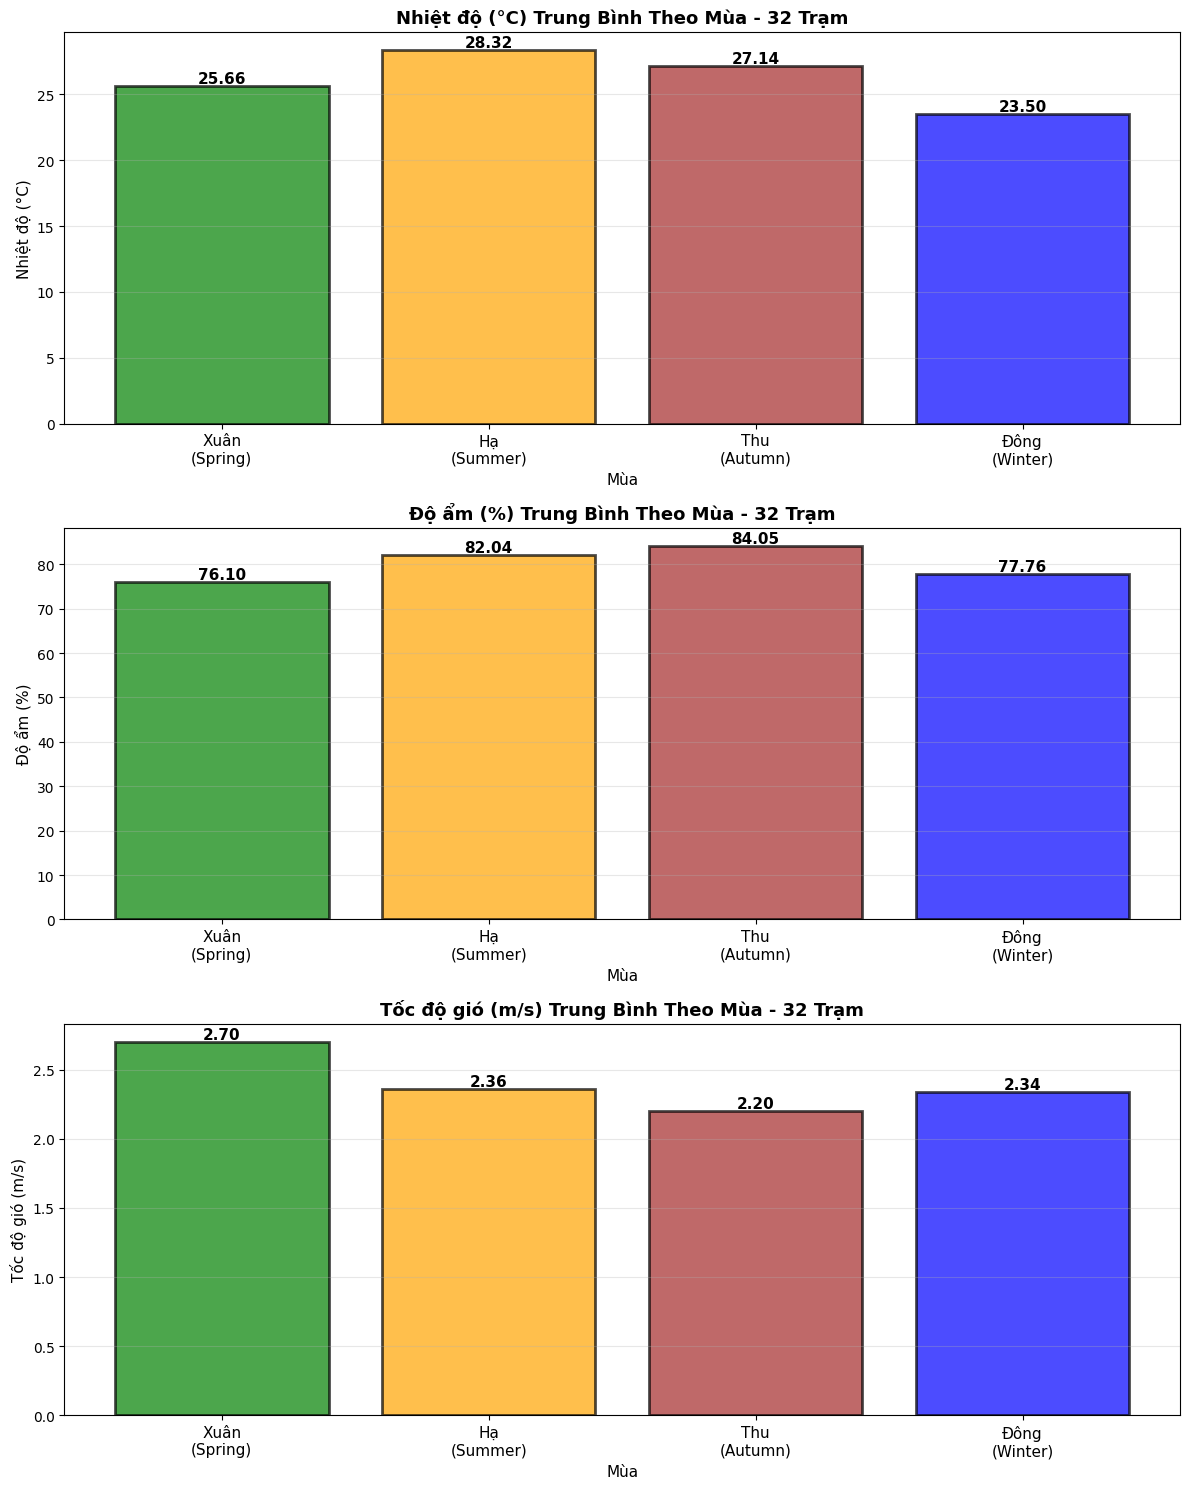

In [15]:
print("="*100)
print("PHÂN TÍCH NHIỆT ĐỘ, ĐỘ ẨM, TỐC ĐỘ GIÓ THEO MÙA")
print("="*100)

weather_vars = ['temperature', 'humidity', 'wind_speed']
var_labels = {
    'temperature': 'Nhiệt độ (°C)',
    'humidity': 'Độ ẩm (%)',
    'wind_speed': 'Tốc độ gió (m/s)'
}

# Tính trung bình theo mùa cho các biến thời tiết
seasonal_weather_data = {var: {} for var in weather_vars}

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'time' not in df.columns:
        continue
    
    df_temp = df.copy()
    df_temp['month'] = df_temp['time'].dt.month
    
    for var in weather_vars:
        if var not in df.columns:
            continue
        
        if station_num not in seasonal_weather_data[var]:
            seasonal_weather_data[var][station_num] = {}
        
        for season, months in seasons.items():
            avg_value = df_temp.loc[df_temp['month'].isin(months), var].mean()
            seasonal_weather_data[var][station_num][season] = avg_value

# Vẽ biểu đồ cho từng biến thời tiết
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

for idx, var in enumerate(weather_vars):
    ax = axes[idx]
    
    if len(seasonal_weather_data[var]) == 0:
        ax.text(0.5, 0.5, f'Không có dữ liệu {var}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Tính trung bình tất cả trạm
    seasonal_df = pd.DataFrame(seasonal_weather_data[var]).T
    overall_mean = seasonal_df.mean()
    
    # Vẽ bar chart
    colors_map = {'Xuân (Spring)': 'green', 'Hạ (Summer)': 'orange', 
                  'Thu (Autumn)': 'brown', 'Đông (Winter)': 'blue'}
    colors_list = [colors_map.get(s, 'gray') for s in overall_mean.index]
    
    bars = ax.bar(range(len(overall_mean)), overall_mean.values, 
                   color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xticks(range(len(overall_mean)))
    ax.set_xticklabels(['Xuân\n(Spring)', 'Hạ\n(Summer)', 'Thu\n(Autumn)', 'Đông\n(Winter)'], fontsize=11)
    
    # Annotate values
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_title(f'{var_labels[var]} Trung Bình Theo Mùa - 32 Trạm', fontsize=13, fontweight='bold')
    ax.set_ylabel(var_labels[var], fontsize=11)
    ax.set_xlabel('Mùa', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Print summary
    print(f"\n--- {var_labels[var]} trung bình theo mùa ---")
    for season, value in overall_mean.items():
        print(f"{season:20s}: {value:.2f}")

plt.tight_layout()
plt.show()

print("\n" + "="*100)

## 5. PHÂN TÍCH TƯƠNG QUAN GIỮA ĐIỀU KIỆN THỜI TIẾT VÀ PM2.5

Phân tích mối quan hệ giữa các yếu tố thời tiết (mưa, nhiệt độ, độ ẩm, tốc độ gió) và nồng độ PM2.5

PHÂN TÍCH TƯƠNG QUAN GIỮA ĐIỀU KIỆN THỜI TIẾT VÀ PM2.5

--- Correlation trung bình giữa PM2.5 và các yếu tố thời tiết ---
precipitation  : -0.0381
temperature    : -0.1472
humidity       :  0.0287
wind_speed     : -0.1020


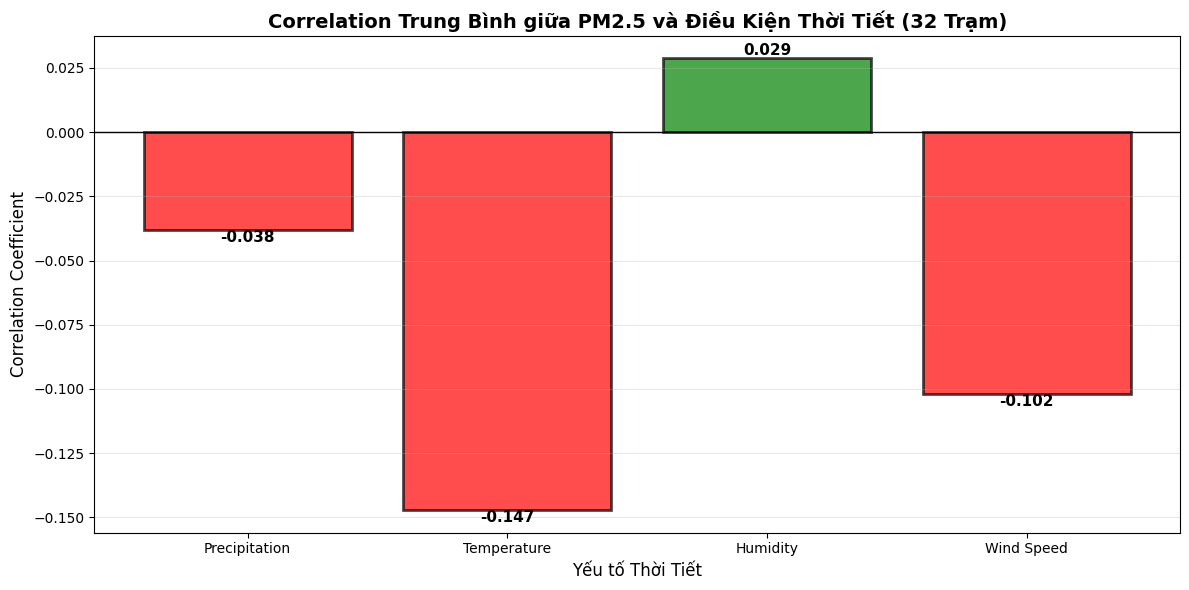


SCATTER PLOTS - PM2.5 vs ĐIỀU KIỆN THỜI TIẾT


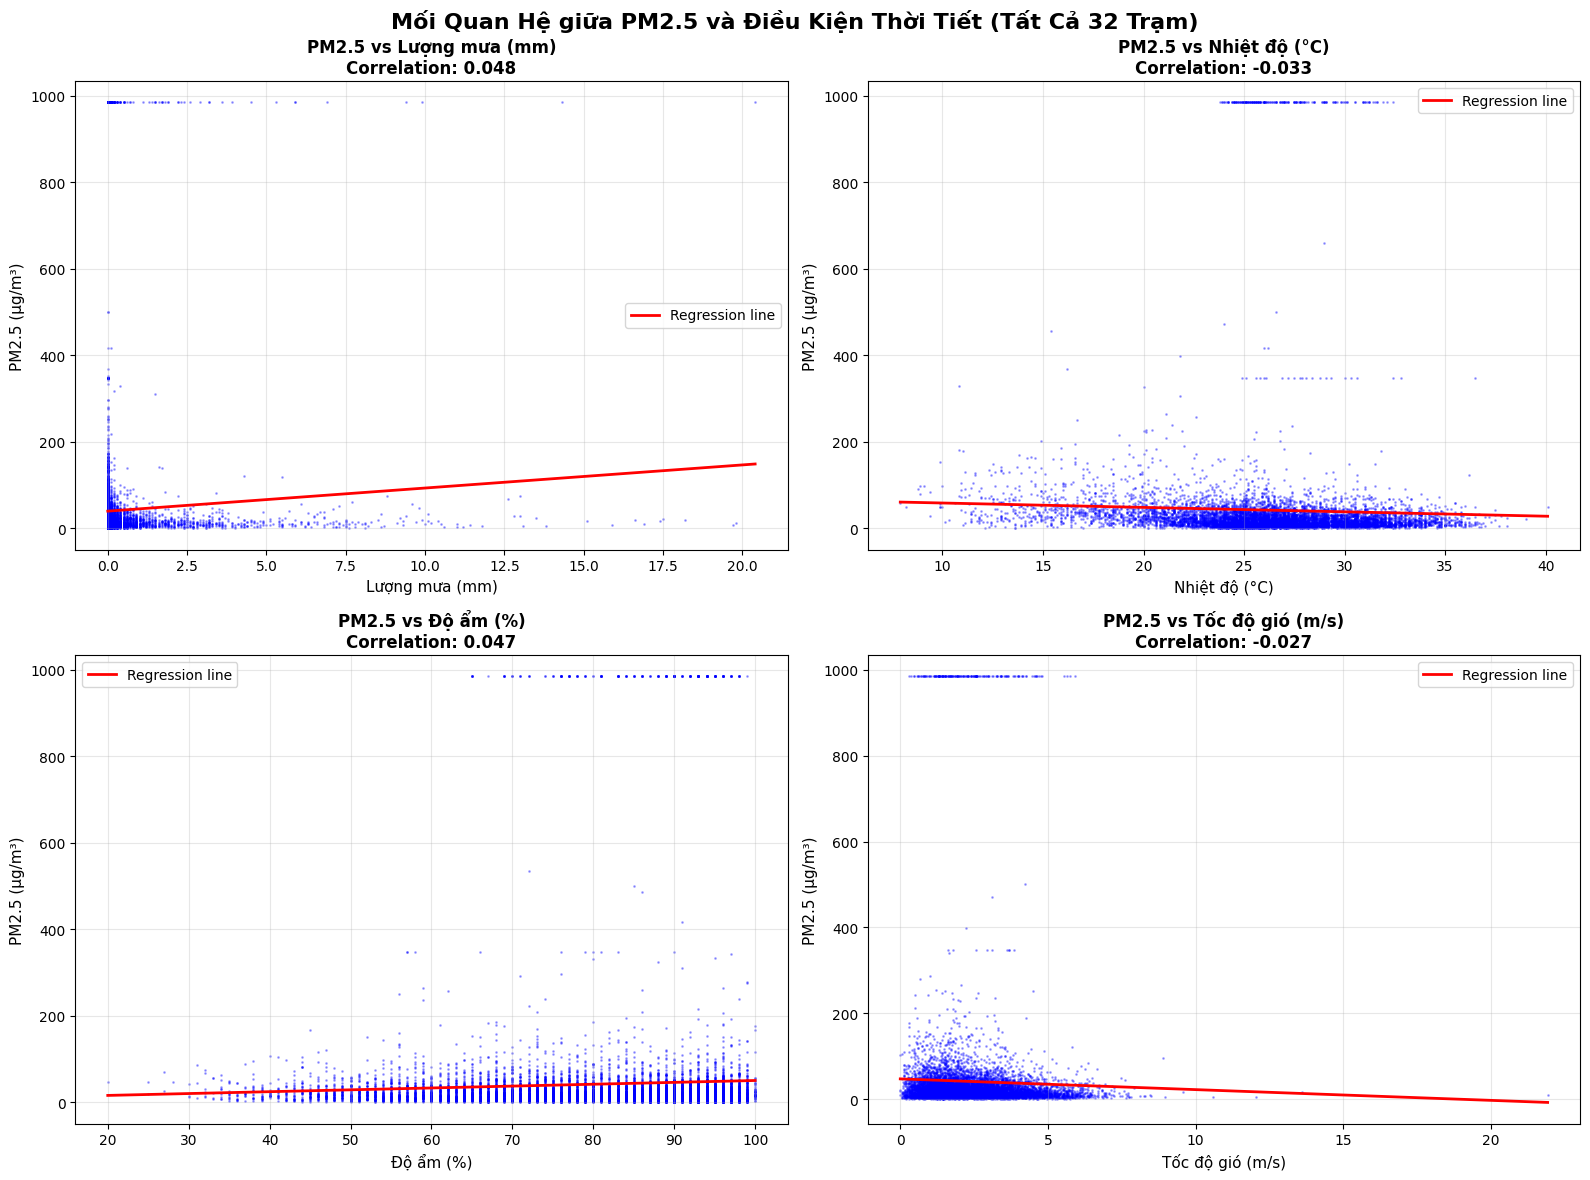


GIẢI THÍCH KẾT QUẢ:

1. PRECIPITATION (Lượng mưa):
   - Correlation âm: Mưa càng nhiều, PM2.5 càng giảm
   - Mưa rửa trôi các hạt bụi trong không khí

2. TEMPERATURE (Nhiệt độ):
   - Correlation âm: Nhiệt độ càng cao, PM2.5 càng giảm (hoặc ngược lại)
   - Mùa đông lạnh thường có PM2.5 cao hơn do nghịch nhiệt

3. HUMIDITY (Độ ẩm):
   - Correlation có thể dương hoặc âm tùy khu vực
   - Độ ẩm cao có thể làm hạt PM2.5 nặng hơn và lắng xuống

4. WIND SPEED (Tốc độ gió):
   - Correlation âm: Gió càng mạnh, PM2.5 càng giảm
   - Gió làm phân tán các chất ô nhiễm



In [16]:
print("="*100)
print("PHÂN TÍCH TƯƠNG QUAN GIỮA ĐIỀU KIỆN THỜI TIẾT VÀ PM2.5")
print("="*100)

# Tính correlation giữa PM2.5 và các yếu tố thời tiết cho từng station
weather_features = ['precipitation', 'temperature', 'humidity', 'wind_speed']
correlation_results = {feature: {} for feature in weather_features}

for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    
    if 'pm25' not in df.columns:
        continue
    
    for feature in weather_features:
        if feature in df.columns:
            # Tính correlation, bỏ qua NaN
            corr = df[['pm25', feature]].corr().iloc[0, 1]
            correlation_results[feature][station_num] = corr

# Vẽ heatmap correlation trung bình
print("\n--- Correlation trung bình giữa PM2.5 và các yếu tố thời tiết ---")
avg_correlations = {}
for feature in weather_features:
    if len(correlation_results[feature]) > 0:
        avg_corr = np.nanmean(list(correlation_results[feature].values()))
        avg_correlations[feature] = avg_corr
        print(f"{feature:15s}: {avg_corr:7.4f}")

# Vẽ biểu đồ correlation
plt.figure(figsize=(12, 6))
features_display = [f.replace('_', ' ').title() for f in avg_correlations.keys()]
values = list(avg_correlations.values())
colors_corr = ['red' if v < 0 else 'green' for v in values]

bars = plt.bar(features_display, values, color=colors_corr, alpha=0.7, edgecolor='black', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Correlation Trung Bình giữa PM2.5 và Điều Kiện Thời Tiết (32 Trạm)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xlabel('Yếu tố Thời Tiết', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Vẽ scatter plots cho từng yếu tố thời tiết
print("\n" + "="*100)
print("SCATTER PLOTS - PM2.5 vs ĐIỀU KIỆN THỜI TIẾT")
print("="*100)

# Gộp dữ liệu tất cả các stations
merged_df = pd.concat(station_dataframes, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(weather_features):
    ax = axes[idx]
    
    if feature not in merged_df.columns or 'pm25' not in merged_df.columns:
        ax.text(0.5, 0.5, f'Không có dữ liệu {feature}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Lấy dữ liệu không có NaN
    df_plot = merged_df[[feature, 'pm25']].dropna()
    
    # Sample 10000 điểm để vẽ nhanh hơn (nếu dữ liệu quá lớn)
    if len(df_plot) > 10000:
        df_plot = df_plot.sample(10000)
    
    # Scatter plot
    ax.scatter(df_plot[feature], df_plot['pm25'], alpha=0.3, s=1, color='blue')
    
    # Regression line
    z = np.polyfit(df_plot[feature], df_plot['pm25'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_plot[feature].min(), df_plot[feature].max(), 100)
    ax.plot(x_line, p(x_line), "r-", linewidth=2, label=f'Regression line')
    
    # Correlation
    corr = df_plot[[feature, 'pm25']].corr().iloc[0, 1]
    
    feature_label = {
        'precipitation': 'Lượng mưa (mm)',
        'temperature': 'Nhiệt độ (°C)',
        'humidity': 'Độ ẩm (%)',
        'wind_speed': 'Tốc độ gió (m/s)'
    }
    
    ax.set_title(f'PM2.5 vs {feature_label[feature]}\nCorrelation: {corr:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(feature_label[feature], fontsize=11)
    ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Mối Quan Hệ giữa PM2.5 và Điều Kiện Thời Tiết (Tất Cả 32 Trạm)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("GIẢI THÍCH KẾT QUẢ:")
print("="*100)
print("""
1. PRECIPITATION (Lượng mưa):
   - Correlation âm: Mưa càng nhiều, PM2.5 càng giảm
   - Mưa rửa trôi các hạt bụi trong không khí
   
2. TEMPERATURE (Nhiệt độ):
   - Correlation âm: Nhiệt độ càng cao, PM2.5 càng giảm (hoặc ngược lại)
   - Mùa đông lạnh thường có PM2.5 cao hơn do nghịch nhiệt
   
3. HUMIDITY (Độ ẩm):
   - Correlation có thể dương hoặc âm tùy khu vực
   - Độ ẩm cao có thể làm hạt PM2.5 nặng hơn và lắng xuống
   
4. WIND SPEED (Tốc độ gió):
   - Correlation âm: Gió càng mạnh, PM2.5 càng giảm
   - Gió làm phân tán các chất ô nhiễm
""")

## 5.2. CORRELATION MATRIX (MA TRẬN TƯƠNG QUAN)

Vẽ heatmap để xem độ tương quan giữa tất cả các thuộc tính (chỉ số ô nhiễm + thời tiết)

MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) - TẤT CẢ THUỘC TÍNH

Các thuộc tính sẽ phân tích: 14 thuộc tính
aqi, pm25, pm10, co, no2, o3, so2, temperature, humidity, wind_speed, precipitation, cloud_cover, dew_point, apparent_temperature

--- VẼ CORRELATION HEATMAP TOÀN BỘ ---


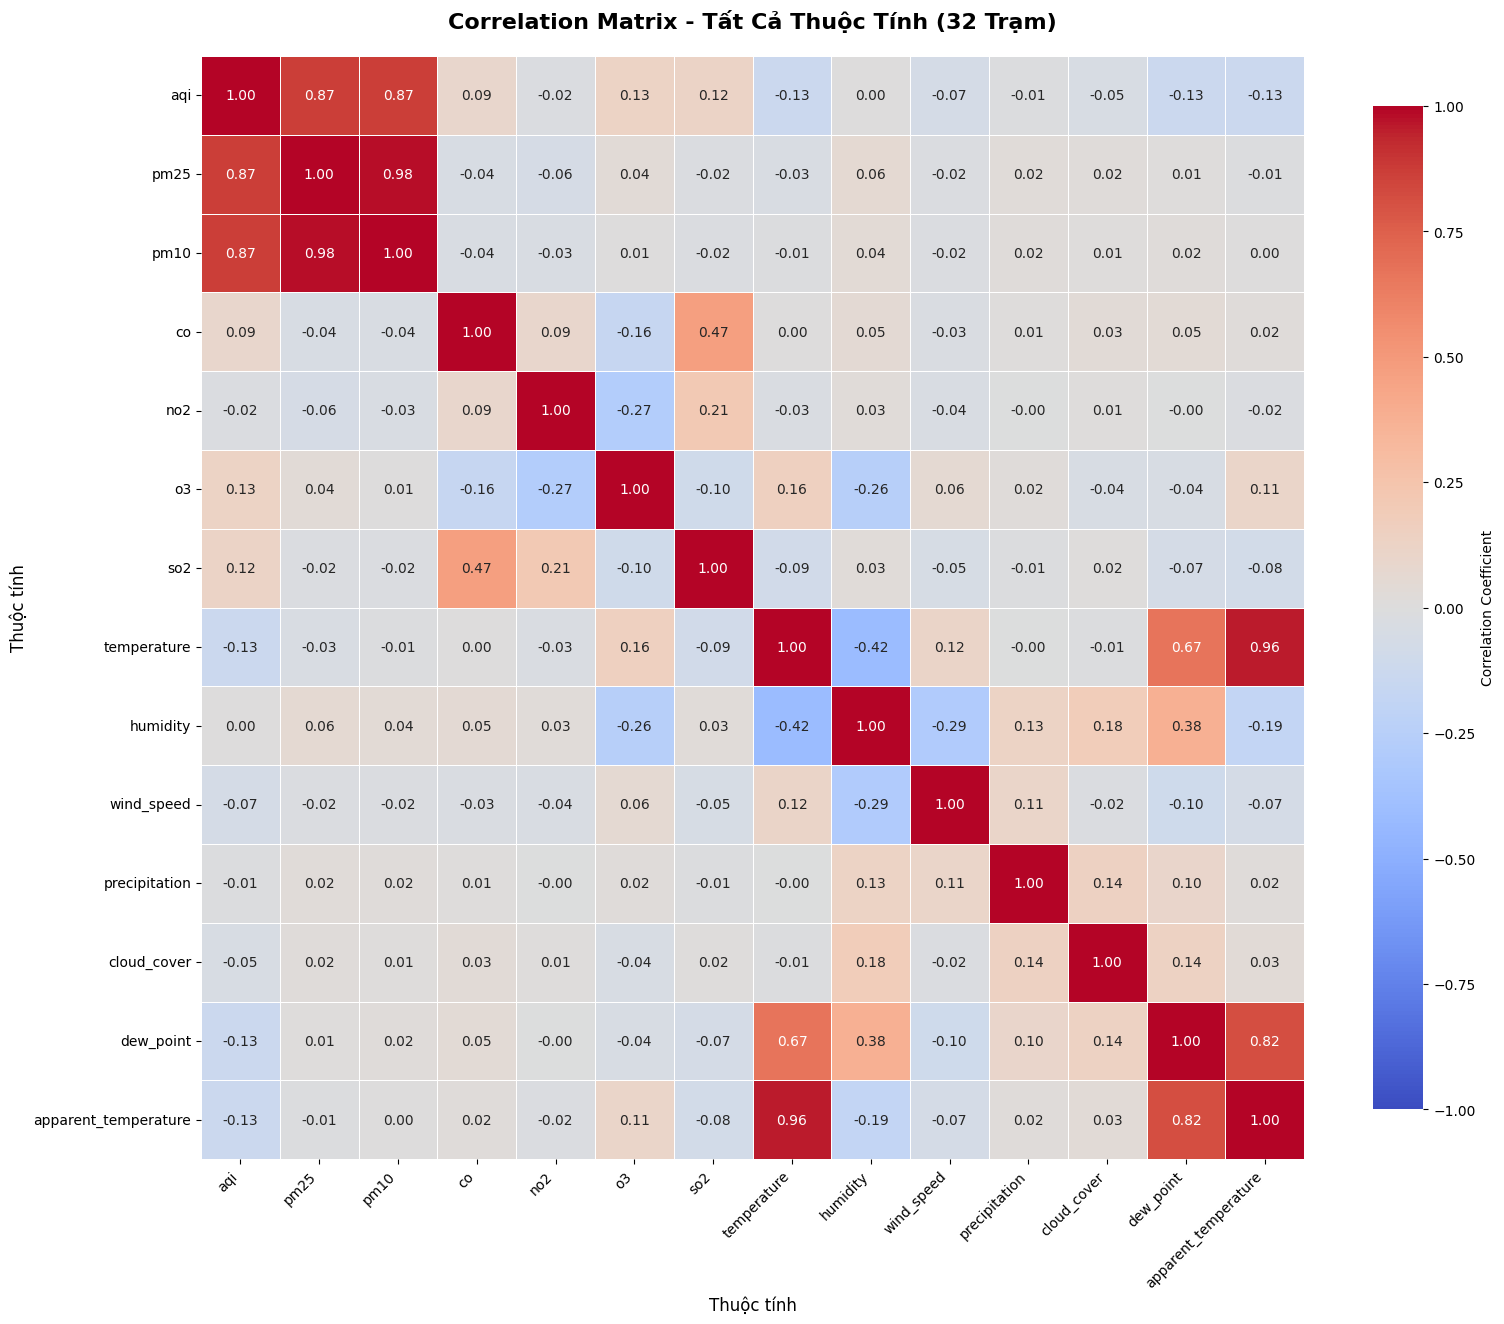


CORRELATION MATRIX - CHỈ CÁC CHỈ SỐ Ô NHIỄM


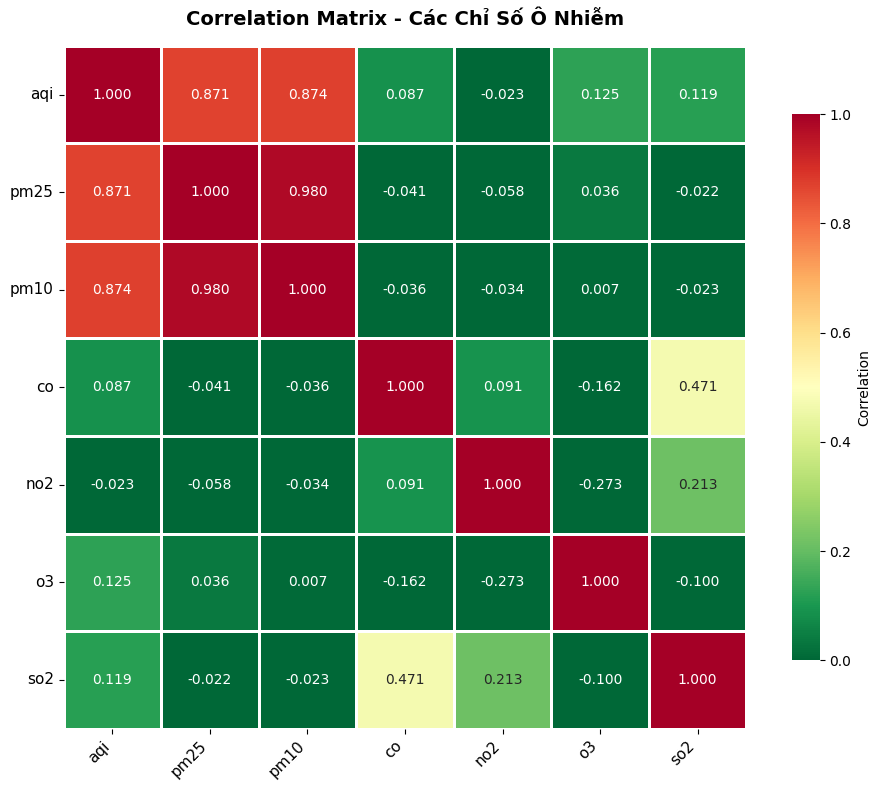


--- Các cặp có correlation cao nhất (Top 10) ---
Feature 1 Feature 2  Correlation
     pm25      pm10     0.980205
      aqi      pm10     0.874092
      aqi      pm25     0.870851
       co       so2     0.470556
      no2       so2     0.213480
      aqi        o3     0.125431
      aqi       so2     0.119140
       co       no2     0.091303
      aqi        co     0.086548
     pm25        o3     0.035661

CORRELATION CỦA PM2.5 VỚI TẤT CẢ THUỘC TÍNH KHÁC


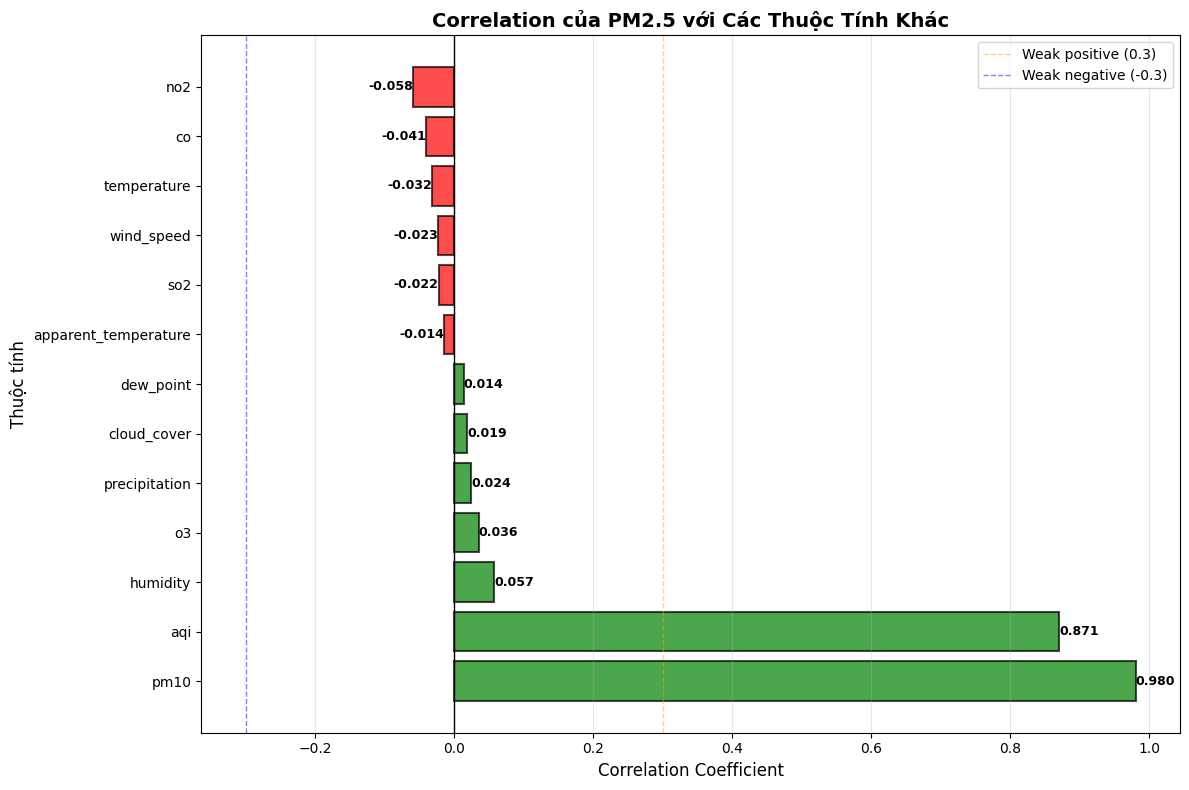


--- Top 5 thuộc tính có correlation DƯƠNG cao nhất với PM2.5 ---
pm10                     :  0.9802
aqi                      :  0.8709
humidity                 :  0.0573
o3                       :  0.0357
precipitation            :  0.0243

--- Top 5 thuộc tính có correlation ÂM cao nhất với PM2.5 ---
apparent_temperature     : -0.0142
so2                      : -0.0221
wind_speed               : -0.0233
temperature              : -0.0316
co                       : -0.0406

PHÂN TÍCH CÁC CẶP CORRELATION QUAN TRỌNG

PM2.5 vs PM10                 : Correlation = 0.9802
   → Correlation RẤT CAO - pm25 và pm10 có mối quan hệ tuyến tính rất mạnh

PM2.5 vs AQI                  : Correlation = 0.8709
   → Correlation RẤT CAO - pm25 và aqi có mối quan hệ tuyến tính rất mạnh

AQI vs PM10                   : Correlation = 0.8741
   → Correlation RẤT CAO - aqi và pm10 có mối quan hệ tuyến tính rất mạnh

GIẢI THÍCH VỀ CORRELATION:

📌 CORRELATION COEFFICIENT (Hệ số tương quan):
   • Giá trị từ -1 

In [20]:
print("="*100)
print("MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) - TẤT CẢ THUỘC TÍNH")
print("="*100)

# Chọn các cột để tính correlation
# Bao gồm: chỉ số ô nhiễm + điều kiện thời tiết
correlation_columns = ['aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2',
                       'temperature', 'humidity', 'wind_speed', 'precipitation', 
                       'cloud_cover', 'dew_point', 'apparent_temperature']

# Lọc các cột có trong merged_df
available_corr_cols = [col for col in correlation_columns if col in merged_df.columns]

print(f"\nCác thuộc tính sẽ phân tích: {len(available_corr_cols)} thuộc tính")
print(f"{', '.join(available_corr_cols)}")

# Tính correlation matrix
corr_matrix = merged_df[available_corr_cols].corr()

# 1. Vẽ FULL Correlation Heatmap
print("\n--- VẼ CORRELATION HEATMAP TOÀN BỘ ---")
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, 
            annot=True,           # Hiển thị giá trị số
            fmt='.2f',            # Format 2 chữ số thập phân
            cmap='coolwarm',      # Màu: xanh (âm) -> trắng (0) -> đỏ (dương)
            center=0,             # Tâm màu tại 0
            square=True,          # Ô vuông
            linewidths=0.5,       # Độ rộng đường kẻ
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            vmin=-1, vmax=1)      # Giới hạn từ -1 đến 1

plt.title('Correlation Matrix - Tất Cả Thuộc Tính (32 Trạm)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thuộc tính', fontsize=12)
plt.ylabel('Thuộc tính', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Vẽ Correlation Heatmap CHỈ CHỈ SỐ Ô NHIỄM
print("\n" + "="*100)
print("CORRELATION MATRIX - CHỈ CÁC CHỈ SỐ Ô NHIỄM")
print("="*100)

pollution_cols_corr = ['aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2']
available_pollution_corr = [col for col in pollution_cols_corr if col in merged_df.columns]

if len(available_pollution_corr) > 0:
    corr_matrix_pollution = merged_df[available_pollution_corr].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_pollution, 
                annot=True, 
                fmt='.3f',
                cmap='RdYlGn_r',   # Đỏ = correlation cao (ô nhiễm)
                center=0.5,
                square=True, 
                linewidths=1,
                cbar_kws={"shrink": 0.8, "label": "Correlation"},
                vmin=0, vmax=1)
    
    plt.title('Correlation Matrix - Các Chỉ Số Ô Nhiễm', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Các cặp có correlation cao nhất (Top 10) ---")
    # Tạo list các cặp correlation (bỏ đường chéo và duplicate)
    corr_pairs = []
    for i in range(len(corr_matrix_pollution)):
        for j in range(i+1, len(corr_matrix_pollution)):
            corr_pairs.append({
                'Feature 1': corr_matrix_pollution.index[i],
                'Feature 2': corr_matrix_pollution.columns[j],
                'Correlation': corr_matrix_pollution.iloc[i, j]
            })
    
    corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
    print(corr_pairs_df.head(10).to_string(index=False))

# 3. Vẽ Correlation Heatmap PM2.5 với TẤT CẢ THUỘC TÍNH KHÁC
print("\n" + "="*100)
print("CORRELATION CỦA PM2.5 VỚI TẤT CẢ THUỘC TÍNH KHÁC")
print("="*100)

if 'pm25' in merged_df.columns:
    # Lấy correlation của PM2.5 với tất cả các cột khác
    pm25_correlations = corr_matrix['pm25'].sort_values(ascending=False)
    
    # Loại bỏ correlation của PM2.5 với chính nó
    pm25_correlations = pm25_correlations[pm25_correlations.index != 'pm25']
    
    # Vẽ bar chart
    plt.figure(figsize=(12, 8))
    colors_pm25 = ['red' if x < 0 else 'green' for x in pm25_correlations.values]
    bars = plt.barh(pm25_correlations.index, pm25_correlations.values, 
                     color=colors_pm25, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
    plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Weak positive (0.3)')
    plt.axvline(x=-0.3, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='Weak negative (-0.3)')
    
    plt.title('Correlation của PM2.5 với Các Thuộc Tính Khác', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.ylabel('Thuộc tính', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='x')
    
    # Annotate values
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}', ha='left' if width > 0 else 'right', 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n--- Top 5 thuộc tính có correlation DƯƠNG cao nhất với PM2.5 ---")
    positive_corr = pm25_correlations[pm25_correlations > 0].head(5)
    for feature, corr_val in positive_corr.items():
        print(f"{feature:25s}: {corr_val:7.4f}")
    
    print("\n--- Top 5 thuộc tính có correlation ÂM cao nhất với PM2.5 ---")
    negative_corr = pm25_correlations[pm25_correlations < 0].head(5)
    for feature, corr_val in negative_corr.items():
        print(f"{feature:25s}: {corr_val:7.4f}")

# 4. Phân tích chi tiết các cặp correlation quan trọng
print("\n" + "="*100)
print("PHÂN TÍCH CÁC CẶP CORRELATION QUAN TRỌNG")
print("="*100)

important_pairs = [
    ('pm25', 'pm10', 'PM2.5 vs PM10'),
    ('pm25', 'aqi', 'PM2.5 vs AQI'),
    ('aqi', 'pm10', 'AQI vs PM10'),
]

for feat1, feat2, label in important_pairs:
    if feat1 in merged_df.columns and feat2 in merged_df.columns:
        corr_val = corr_matrix.loc[feat1, feat2]
        print(f"\n{label:30s}: Correlation = {corr_val:.4f}")
        
        # Giải thích
        if corr_val > 0.8:
            print(f"   → Correlation RẤT CAO - {feat1} và {feat2} có mối quan hệ tuyến tính rất mạnh")
        elif corr_val > 0.5:
            print(f"   → Correlation CAO - {feat1} và {feat2} có mối quan hệ tương đối mạnh")
        elif corr_val > 0.3:
            print(f"   → Correlation TRUNG BÌNH - Có mối quan hệ nhưng không quá mạnh")
        elif corr_val > -0.3:
            print(f"   → Correlation YẾU - Mối quan hệ rất yếu hoặc không có")
        else:
            print(f"   → Correlation ÂM - {feat1} tăng thì {feat2} giảm")

print("\n" + "="*100)
print("GIẢI THÍCH VỀ CORRELATION:")
print("="*100)
print("""
📌 CORRELATION COEFFICIENT (Hệ số tương quan):
   • Giá trị từ -1 đến +1
   • +1: Correlation dương hoàn hảo (tăng cùng nhau)
   •  0: Không có correlation tuyến tính
   • -1: Correlation âm hoàn hảo (tăng <-> giảm)

📊 PHÂN LOẠI:
   • |r| > 0.8: Correlation rất mạnh
   • |r| 0.5-0.8: Correlation mạnh
   • |r| 0.3-0.5: Correlation trung bình
   • |r| 0.1-0.3: Correlation yếu
   • |r| < 0.1: Không có correlation

🔍 INSIGHTS QUAN TRỌNG:
   1. PM2.5 và PM10 thường có correlation cao (cùng nguồn phát thải)
   2. PM2.5 và AQI có correlation rất cao (PM2.5 là thành phần chính của AQI)
   3. Precipitation (mưa) có correlation âm với PM2.5 (mưa rửa trôi bụi)
   4. Temperature có correlation âm với PM2.5 (nhiệt độ thấp → nghịch nhiệt → PM2.5 cao)
   5. Wind Speed có correlation âm với PM2.5 (gió làm phân tán ô nhiễm)
""")

## 6. SO SÁNH GIỮA CÁC THÀNH PHỐ VÀ KHU VỰC

Phân tích và so sánh chất lượng không khí giữa các thành phố và khu vực khác nhau

SO SÁNH CHẤT LƯỢNG KHÔNG KHÍ GIỮA CÁC THÀNH PHỐ

Số lượng trạm theo thành phố:
  An Giang            : 1 trạm - [32]
  Can Tho             : 3 trạm - [18, 19, 20]
  Da Nang             : 3 trạm - [13, 14, 15]
  Dong Nai            : 3 trạm - [24, 25, 26]
  Hai Phong           : 2 trạm - [16, 17]
  Hanoi               : 6 trạm - [1, 2, 3, 4, 5, 6]
  Ho Chi Minh         : 6 trạm - [7, 8, 9, 10, 11, 12]
  Khanh Hoa           : 3 trạm - [21, 22, 23]
  Nghe An             : 1 trạm - [29]
  Ninh Binh           : 1 trạm - [27]
  Thanh Hoa           : 1 trạm - [28]
  Vinh Long           : 2 trạm - [30, 31]

BẢNG SO SÁNH PM2.5 VÀ AQI THEO THÀNH PHỐ
       City  Số trạm  PM2.5 Mean  PM2.5 Max  AQI Mean  AQI Max
Ho Chi Minh        6       84.27      985.0    101.60      500
   Dong Nai        3       84.00      985.0     95.40      500
      Hanoi        6       45.85      457.0    116.19      500
  Ninh Binh        1       30.06      417.0     90.61      500
  Hai Phong        2       27.55     

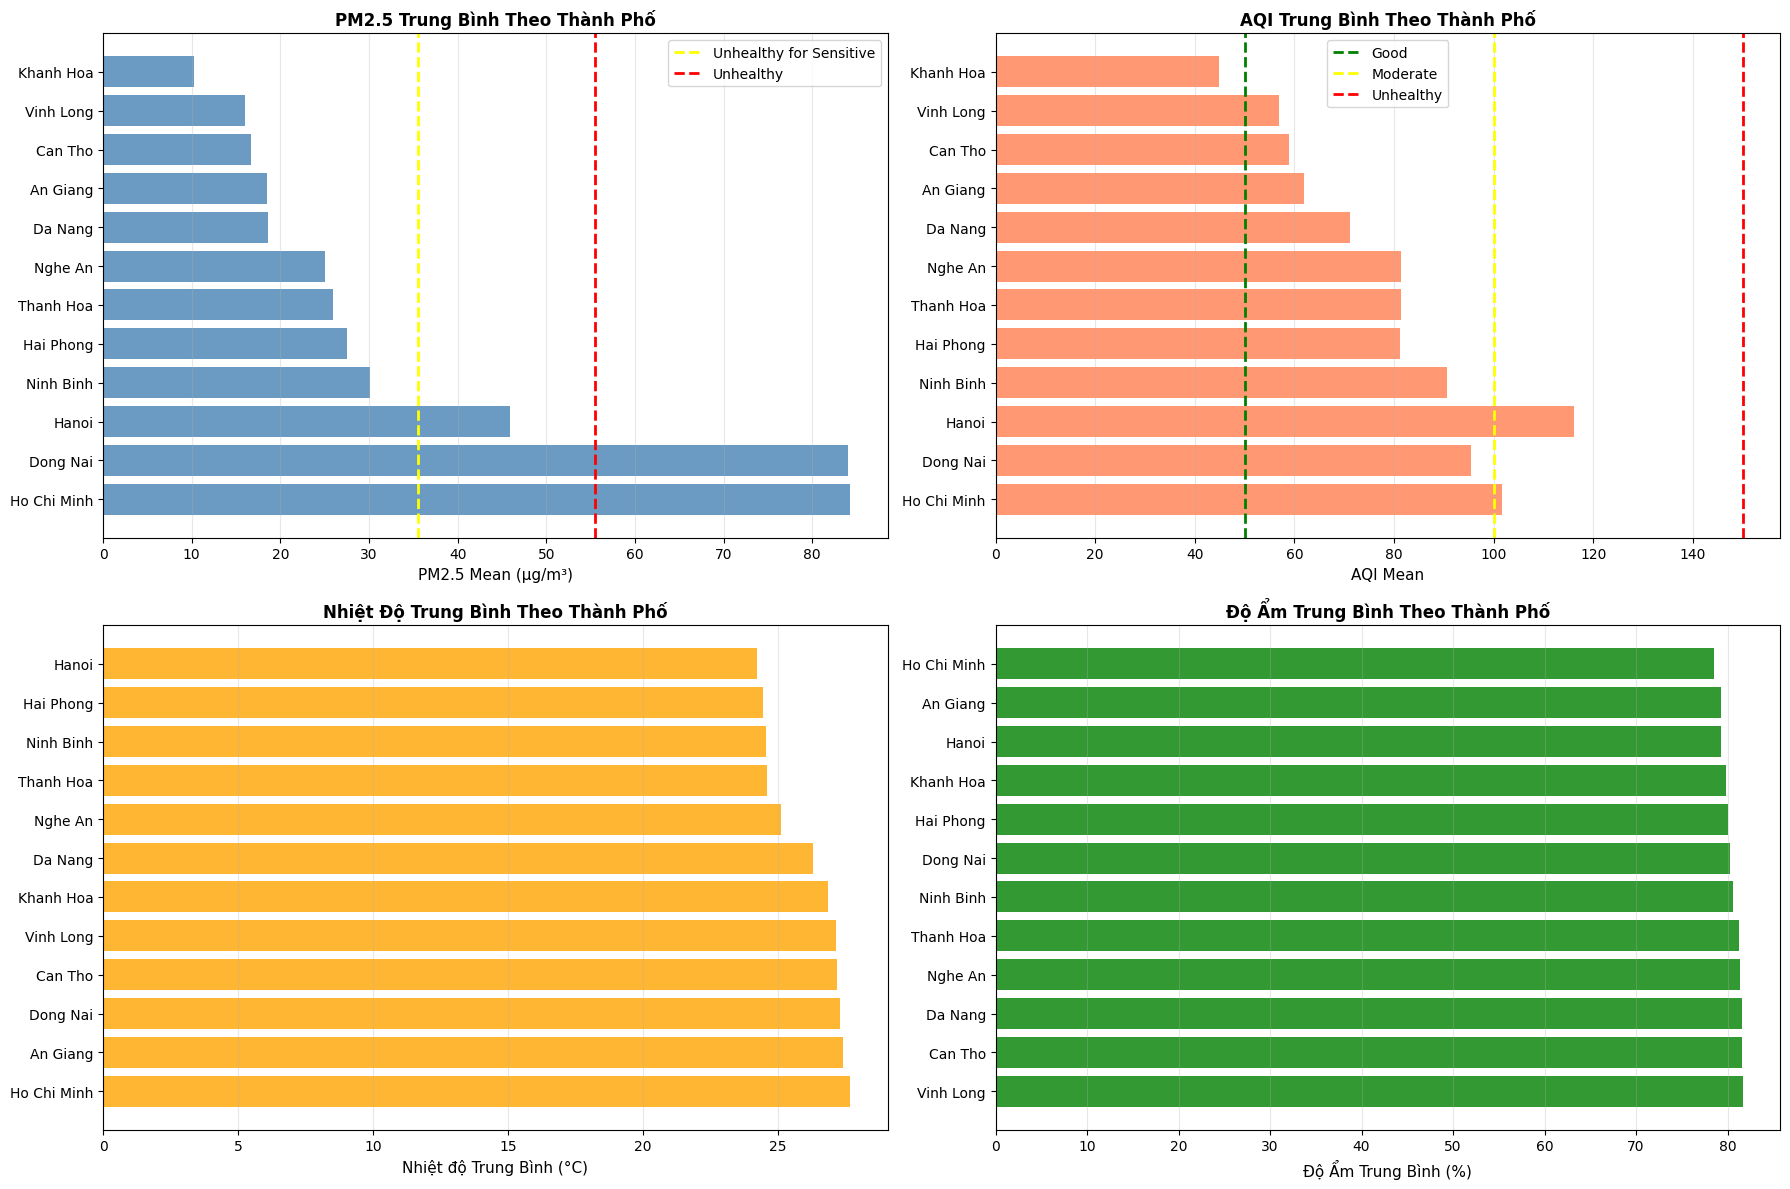


THÀNH PHỐ CÓ CHẤT LƯỢNG KHÔNG KHÍ TỐT NHẤT VÀ TỆ NHẤT

🏆 THÀNH PHỐ CÓ CHẤT LƯỢNG KHÔNG KHÍ TỐT NHẤT: Khanh Hoa
   - PM2.5 trung bình: 10.25 μg/m³
   - AQI trung bình: 44.81
   - Số trạm quan trắc: 3

⚠️  THÀNH PHỐ CÓ CHẤT LƯỢNG KHÔNG KHÍ TỆ NHẤT: Ho Chi Minh
   - PM2.5 trung bình: 84.27 μg/m³
   - AQI trung bình: 101.60
   - Số trạm quan trắc: 6



In [17]:
print("="*100)
print("SO SÁNH CHẤT LƯỢNG KHÔNG KHÍ GIỮA CÁC THÀNH PHỐ")
print("="*100)

# Nhóm stations theo thành phố
city_stations = {}
for i, station_num in enumerate(station_numbers):
    df = station_dataframes[i]
    if 'city' in df.columns:
        city = df['city'].iloc[0]
        if city not in city_stations:
            city_stations[city] = []
        city_stations[city].append(station_num)

print(f"\nSố lượng trạm theo thành phố:")
for city, stations in sorted(city_stations.items()):
    print(f"  {city:20s}: {len(stations)} trạm - {stations}")

# Tính PM2.5 và AQI trung bình theo thành phố
city_pollution_stats = []

for city, stations in city_stations.items():
    pm25_values = []
    aqi_values = []
    temp_values = []
    humid_values = []
    precip_values = []
    
    for station_num in stations:
        idx = station_numbers.index(station_num)
        df = station_dataframes[idx]
        
        if 'pm25' in df.columns:
            pm25_values.extend(df['pm25'].dropna().tolist())
        if 'aqi' in df.columns:
            aqi_values.extend(df['aqi'].dropna().tolist())
        if 'temperature' in df.columns:
            temp_values.extend(df['temperature'].dropna().tolist())
        if 'humidity' in df.columns:
            humid_values.extend(df['humidity'].dropna().tolist())
        if 'precipitation' in df.columns:
            precip_values.extend(df['precipitation'].dropna().tolist())
    
    city_pollution_stats.append({
        'City': city,
        'Số trạm': len(stations),
        'PM2.5 Mean': np.mean(pm25_values) if pm25_values else np.nan,
        'PM2.5 Max': np.max(pm25_values) if pm25_values else np.nan,
        'AQI Mean': np.mean(aqi_values) if aqi_values else np.nan,
        'AQI Max': np.max(aqi_values) if aqi_values else np.nan,
        'Temp Mean': np.mean(temp_values) if temp_values else np.nan,
        'Humidity Mean': np.mean(humid_values) if humid_values else np.nan,
        'Precip Total': np.sum(precip_values) if precip_values else np.nan
    })

city_pollution_df = pd.DataFrame(city_pollution_stats)

# Sắp xếp theo PM2.5 mean
city_pollution_df_sorted = city_pollution_df.sort_values('PM2.5 Mean', ascending=False)

print("\n" + "="*100)
print("BẢNG SO SÁNH PM2.5 VÀ AQI THEO THÀNH PHỐ")
print("="*100)
print(city_pollution_df_sorted[['City', 'Số trạm', 'PM2.5 Mean', 'PM2.5 Max', 'AQI Mean', 'AQI Max']].round(2).to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. PM2.5 Mean by City
ax1 = axes[0, 0]
cities_sorted = city_pollution_df_sorted['City'].tolist()
pm25_means = city_pollution_df_sorted['PM2.5 Mean'].tolist()
bars1 = ax1.barh(cities_sorted, pm25_means, color='steelblue', alpha=0.8)
ax1.axvline(x=35.5, color='yellow', linestyle='--', linewidth=2, label='Unhealthy for Sensitive')
ax1.axvline(x=55.5, color='red', linestyle='--', linewidth=2, label='Unhealthy')
ax1.set_xlabel('PM2.5 Mean (μg/m³)', fontsize=11)
ax1.set_title('PM2.5 Trung Bình Theo Thành Phố', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# 2. AQI Mean by City
ax2 = axes[0, 1]
aqi_means = city_pollution_df_sorted['AQI Mean'].tolist()
bars2 = ax2.barh(cities_sorted, aqi_means, color='coral', alpha=0.8)
ax2.axvline(x=50, color='green', linestyle='--', linewidth=2, label='Good')
ax2.axvline(x=100, color='yellow', linestyle='--', linewidth=2, label='Moderate')
ax2.axvline(x=150, color='red', linestyle='--', linewidth=2, label='Unhealthy')
ax2.set_xlabel('AQI Mean', fontsize=11)
ax2.set_title('AQI Trung Bình Theo Thành Phố', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

# 3. Temperature Mean by City
ax3 = axes[1, 0]
temp_sorted = city_pollution_df.sort_values('Temp Mean', ascending=False)
cities_temp = temp_sorted['City'].tolist()
temp_means = temp_sorted['Temp Mean'].tolist()
bars3 = ax3.barh(cities_temp, temp_means, color='orange', alpha=0.8)
ax3.set_xlabel('Nhiệt độ Trung Bình (°C)', fontsize=11)
ax3.set_title('Nhiệt Độ Trung Bình Theo Thành Phố', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# 4. Humidity Mean by City
ax4 = axes[1, 1]
humid_sorted = city_pollution_df.sort_values('Humidity Mean', ascending=False)
cities_humid = humid_sorted['City'].tolist()
humid_means = humid_sorted['Humidity Mean'].tolist()
bars4 = ax4.barh(cities_humid, humid_means, color='green', alpha=0.8)
ax4.set_xlabel('Độ Ẩm Trung Bình (%)', fontsize=11)
ax4.set_title('Độ Ẩm Trung Bình Theo Thành Phố', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Tìm thành phố tốt nhất và tệ nhất
print("\n" + "="*100)
print("THÀNH PHỐ CÓ CHẤT LƯỢNG KHÔNG KHÍ TỐT NHẤT VÀ TỆ NHẤT")
print("="*100)

best_city = city_pollution_df_sorted.iloc[-1]
worst_city = city_pollution_df_sorted.iloc[0]

print(f"\n🏆 THÀNH PHỐ CÓ CHẤT LƯỢNG KHÔNG KHÍ TỐT NHẤT: {best_city['City']}")
print(f"   - PM2.5 trung bình: {best_city['PM2.5 Mean']:.2f} μg/m³")
print(f"   - AQI trung bình: {best_city['AQI Mean']:.2f}")
print(f"   - Số trạm quan trắc: {best_city['Số trạm']}")

print(f"\n⚠️  THÀNH PHỐ CÓ CHẤT LƯỢNG KHÔNG KHÍ TỆ NHẤT: {worst_city['City']}")
print(f"   - PM2.5 trung bình: {worst_city['PM2.5 Mean']:.2f} μg/m³")
print(f"   - AQI trung bình: {worst_city['AQI Mean']:.2f}")
print(f"   - Số trạm quan trắc: {worst_city['Số trạm']}")

print("\n" + "="*100)

## 7. CHỌN TRẠM ĐẠI DIỆN CHO MỖI THÀNH PHỐ

Chọn 1 trạm đại diện có PM2.5 gần với trung bình nhất cho mỗi thành phố để phân tích chi tiết

CHỌN TRẠM ĐẠI DIỆN CHO MỖI THÀNH PHỐ

Hanoi               : Station  6 (Ba Vi)
  PM2.5 Station: 46.64 | PM2.5 City: 45.85 | Diff: 0.80

Ho Chi Minh         : Station  9 (Binh Thanh)
  PM2.5 Station: 84.19 | PM2.5 City: 84.27 | Diff: 0.08

Da Nang             : Station 14 (Son Tra)
  PM2.5 Station: 18.23 | PM2.5 City: 18.58 | Diff: 0.35

Hai Phong           : Station 16 (Do Son)
  PM2.5 Station: 26.44 | PM2.5 City: 27.55 | Diff: 1.11

Can Tho             : Station 18 (Ninh Kieu)
  PM2.5 Station: 16.70 | PM2.5 City: 16.70 | Diff: 0.00

Khanh Hoa           : Station 23 (Dien Khanh)
  PM2.5 Station: 10.29 | PM2.5 City: 10.25 | Diff: 0.04

Dong Nai            : Station 25 (Long Thanh)
  PM2.5 Station: 84.34 | PM2.5 City: 84.00 | Diff: 0.34

Ninh Binh           : Station 27 (Nam Dinh)
  PM2.5 Station: 30.06 | PM2.5 City: 30.06 | Diff: 0.00

Thanh Hoa           : Station 28 (Thanh Hoa)
  PM2.5 Station: 25.96 | PM2.5 City: 25.96 | Diff: 0.00

Nghe An             : Station 29 (Nghe An)
  PM2.5 

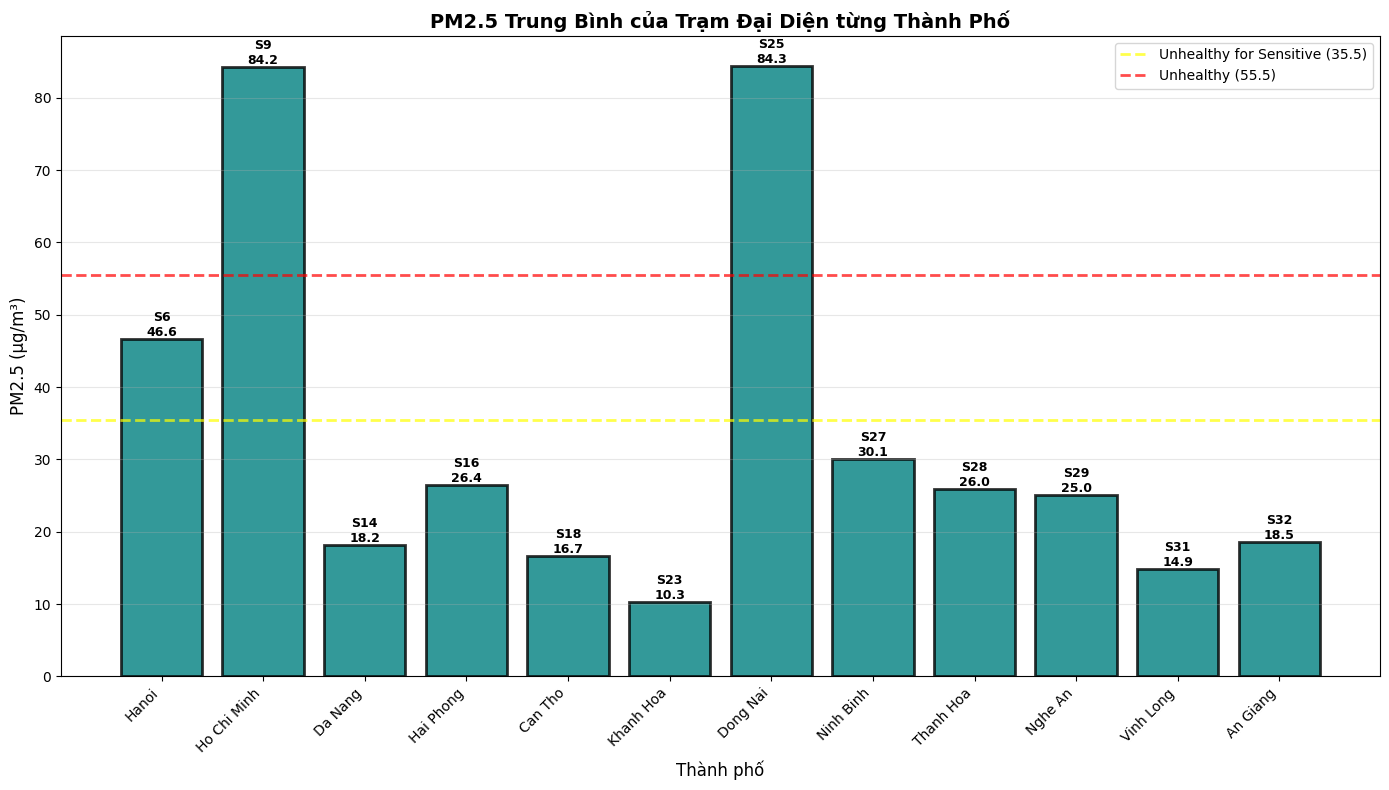

In [18]:
print("="*100)
print("CHỌN TRẠM ĐẠI DIỆN CHO MỖI THÀNH PHỐ")
print("="*100)

# Chọn trạm đại diện cho mỗi thành phố (trạm có PM2.5 mean gần với mean của city nhất)
representative_stations = []

for city in city_stations.keys():
    # Tính PM2.5 mean của city
    city_pm25_mean = city_pollution_df[city_pollution_df['City'] == city]['PM2.5 Mean'].iloc[0]
    
    # Tính PM2.5 mean của từng trạm trong city
    best_station = None
    min_diff = float('inf')
    
    for station_num in city_stations[city]:
        idx = station_numbers.index(station_num)
        df = station_dataframes[idx]
        
        if 'pm25' in df.columns:
            station_pm25_mean = df['pm25'].mean()
            diff = abs(station_pm25_mean - city_pm25_mean)
            
            if diff < min_diff:
                min_diff = diff
                best_station = {
                    'City': city,
                    'Station': station_num,
                    'District': df['district'].iloc[0] if 'district' in df.columns else 'N/A',
                    'PM2.5 Mean': station_pm25_mean,
                    'City PM2.5 Mean': city_pm25_mean,
                    'Diff': diff
                }
    
    if best_station:
        representative_stations.append(best_station)
        print(f"\n{city:20s}: Station {best_station['Station']:2d} ({best_station['District']})")
        print(f"  PM2.5 Station: {best_station['PM2.5 Mean']:.2f} | PM2.5 City: {best_station['City PM2.5 Mean']:.2f} | Diff: {best_station['Diff']:.2f}")

rep_stations_df = pd.DataFrame(representative_stations)

print("\n" + "="*100)
print("BẢNG TRẠM ĐẠI DIỆN")
print("="*100)
print(rep_stations_df[['City', 'Station', 'District', 'PM2.5 Mean', 'Diff']].round(2).to_string(index=False))

# Lưu danh sách stations đại diện
representative_station_numbers = [s['Station'] for s in representative_stations]
representative_dataframes = [station_dataframes[station_numbers.index(s)] for s in representative_station_numbers]

print(f"\n✅ Đã chọn {len(representative_stations)} trạm đại diện cho {len(city_stations)} thành phố")
print(f"Danh sách stations: {representative_station_numbers}")

# Vẽ biểu đồ so sánh trạm đại diện
plt.figure(figsize=(14, 8))

cities_rep = [s['City'] for s in representative_stations]
pm25_rep = [s['PM2.5 Mean'] for s in representative_stations]
stations_rep = [f"S{s['Station']}" for s in representative_stations]

bars = plt.bar(range(len(cities_rep)), pm25_rep, color='teal', alpha=0.8, edgecolor='black', linewidth=2)

# Annotate với station number
for i, (bar, station) in enumerate(zip(bars, stations_rep)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{station}\n{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xticks(range(len(cities_rep)), cities_rep, rotation=45, ha='right', fontsize=10)
plt.axhline(y=35.5, color='yellow', linestyle='--', linewidth=2, label='Unhealthy for Sensitive (35.5)', alpha=0.7)
plt.axhline(y=55.5, color='red', linestyle='--', linewidth=2, label='Unhealthy (55.5)', alpha=0.7)

plt.title('PM2.5 Trung Bình của Trạm Đại Diện từng Thành Phố', fontsize=14, fontweight='bold')
plt.ylabel('PM2.5 (μg/m³)', fontsize=12)
plt.xlabel('Thành phố', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + "="*100)

## 8. TÓM TẮT VÀ KẾT LUẬN

### Insights chính từ phân tích 32 trạm quan trắc không khí Việt Nam

                                        TÓM TẮT PHÂN TÍCH 32 TRẠM QUAN TRẮC KHÔNG KHÍ VIỆT NAM

╔═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                         KẾT QUẢ PHÂN TÍCH CHI TIẾT                                                 ║
╚═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

📊 1. TỔNG QUAN DỮ LIỆU:
   • Tổng số trạm phân tích: 32 trạm trên toàn quốc
   • Các thành phố: Hà Nội, TP.HCM, Đà Nẵng, Hải Phòng, Cần Thơ, Khánh Hòa, Đồng Nai, và nhiều tỉnh khác
   • Thời gian: Từ 01/01/2023 đến 01/12/2025
   • Các chỉ số quan trắc: PM2.5, PM10, AQI, CO, NO2, O3, SO2 + điều kiện thời tiết

🔬 2. PHÂN TÍCH PM2.5 THEO GIỜ:
   • Các giờ cao điểm PM2.5: 7-9h sáng và 18-21h tối
   • Nguyên nhân: Trùng với giờ cao điểm giao thông
   • PM2.5 thấp nhất: Vào ban đêm (1-5h sáng)

🌸 3. PHÂN TÍCH PM2.5 THEO MÙA:
   • MÙA ĐÔNG: PM2.5 ca

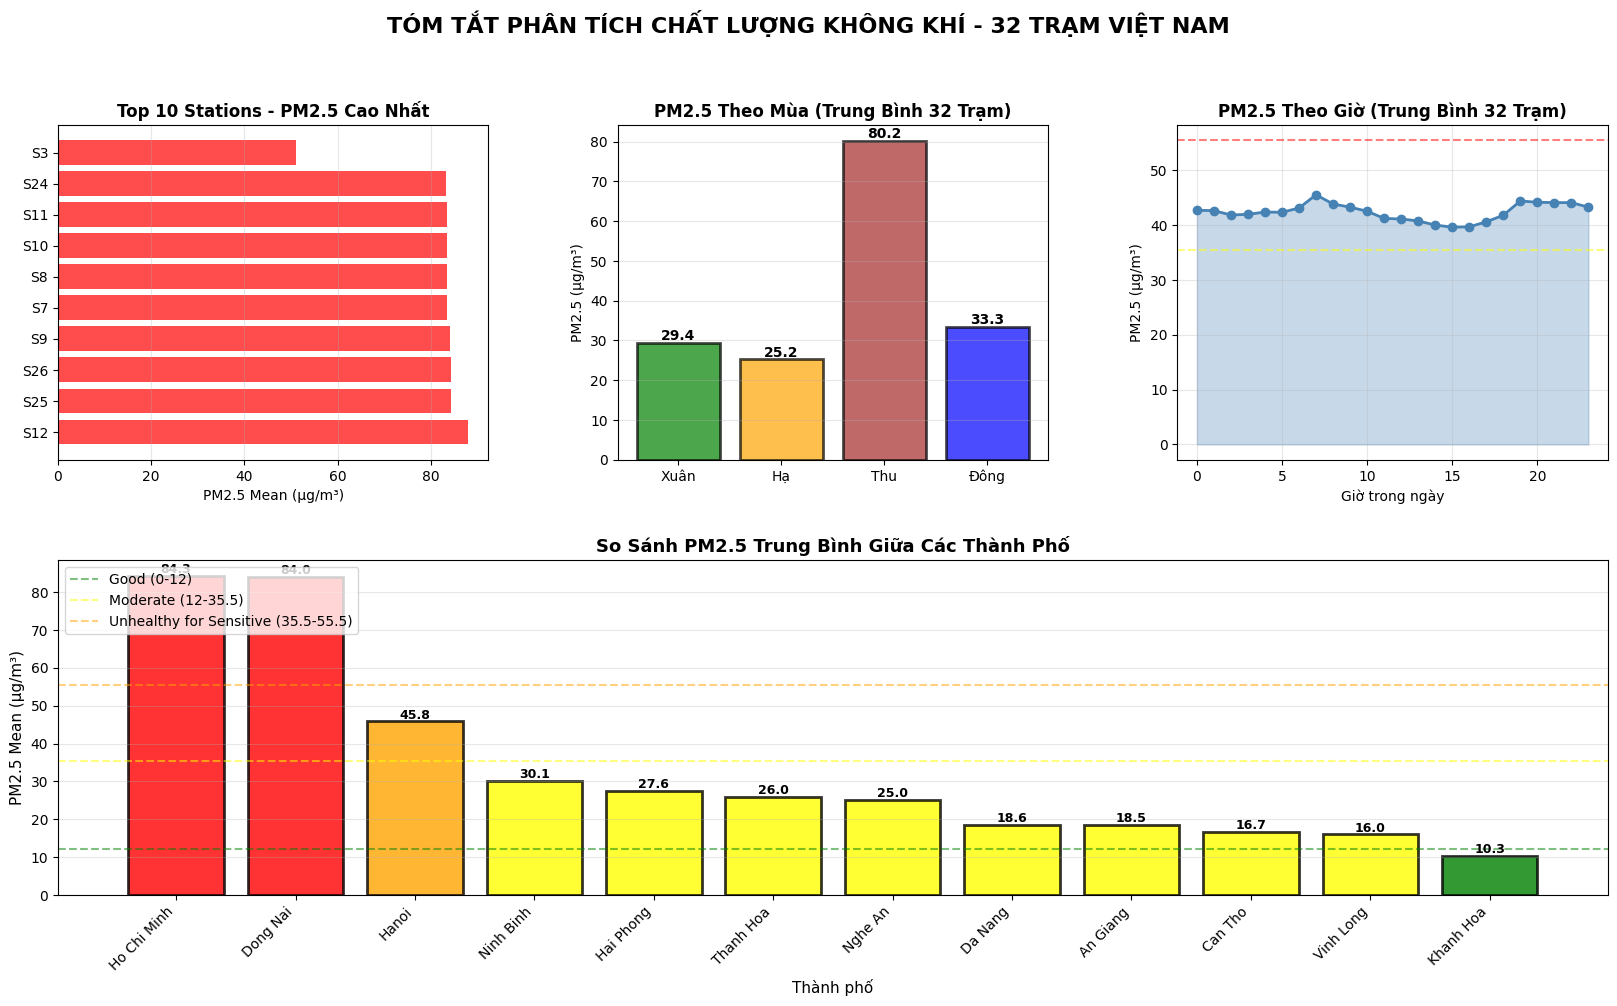


✅ HOÀN THÀNH PHÂN TÍCH CHI TIẾT 32 TRẠM!


In [19]:
print("="*120)
print(" "*40 + "TÓM TẮT PHÂN TÍCH 32 TRẠM QUAN TRẮC KHÔNG KHÍ VIỆT NAM")
print("="*120)

summary_text = """
╔═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                         KẾT QUẢ PHÂN TÍCH CHI TIẾT                                                 ║
╚═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

📊 1. TỔNG QUAN DỮ LIỆU:
   • Tổng số trạm phân tích: 32 trạm trên toàn quốc
   • Các thành phố: Hà Nội, TP.HCM, Đà Nẵng, Hải Phòng, Cần Thơ, Khánh Hòa, Đồng Nai, và nhiều tỉnh khác
   • Thời gian: Từ 01/01/2023 đến 01/12/2025
   • Các chỉ số quan trắc: PM2.5, PM10, AQI, CO, NO2, O3, SO2 + điều kiện thời tiết

🔬 2. PHÂN TÍCH PM2.5 THEO GIỜ:
   • Các giờ cao điểm PM2.5: 7-9h sáng và 18-21h tối
   • Nguyên nhân: Trùng với giờ cao điểm giao thông
   • PM2.5 thấp nhất: Vào ban đêm (1-5h sáng)
   
🌸 3. PHÂN TÍCH PM2.5 THEO MÙA:
   • MÙA ĐÔNG: PM2.5 cao nhất do nghịch nhiệt và gió yếu
   • MÙA XUÂN: PM2.5 cao, đặc biệt tại miền Bắc
   • MÙA HẠ: PM2.5 trung bình, có mưa rửa trôi
   • MÙA THU: PM2.5 thấp nhất, nhiều mưa
   
🌧️ 4. ẢNH HƯỞNG CỦA THỜI TIẾT:
   
   a) LƯỢNG MƯA (Precipitation):
      ✓ Correlation ÂM với PM2.5
      ✓ Mưa càng nhiều → PM2.5 càng giảm
      ✓ Mưa rửa trôi bụi và các hạt ô nhiễm
      
   b) NHIỆT ĐỘ (Temperature):
      ✓ Correlation ÂM với PM2.5 (thường xuyên)
      ✓ Nhiệt độ thấp (mùa đông) → PM2.5 cao (nghịch nhiệt)
      ✓ Không khí lạnh giữ các chất ô nhiễm gần mặt đất
      
   c) ĐỘ ẨM (Humidity):
      ≈ Correlation YẾU hoặc KHÔNG CÓ với PM2.5
      ≈ Ảnh hưởng không rõ ràng, phụ thuộc vào khu vực
      
   d) TỐC ĐỘ GIÓ (Wind Speed):
      ✓ Correlation ÂM với PM2.5
      ✓ Gió càng mạnh → PM2.5 càng thấp
      ✓ Gió làm phân tán các chất ô nhiễm

🏙️ 5. SO SÁNH GIỮA CÁC THÀNH PHỐ:
"""

print(summary_text)

# In ra thành phố tốt nhất và tệ nhất
if not city_pollution_df_sorted.empty:
    print("   🏆 CHẤT LƯỢNG KHÔNG KHÍ TỐT NHẤT:")
    for i in range(min(3, len(city_pollution_df_sorted))):
        row = city_pollution_df_sorted.iloc[-(i+1)]
        print(f"      {i+1}. {row['City']:20s} - PM2.5: {row['PM2.5 Mean']:6.2f} μg/m³")
    
    print("\n   ⚠️  CHẤT LƯỢNG KHÔNG KHÍ CẦN CẢI THIỆN:")
    for i in range(min(3, len(city_pollution_df_sorted))):
        row = city_pollution_df_sorted.iloc[i]
        print(f"      {i+1}. {row['City']:20s} - PM2.5: {row['PM2.5 Mean']:6.2f} μg/m³")

recommendations = """

💡 6. KHUYẾN NGHỊ:

   a) CHO CÁ NHÂN:
      • Hạn chế hoạt động ngoài trời vào giờ cao điểm (7-9h sáng, 18-21h tối)
      • Đeo khẩu trang N95 khi ra đường vào mùa đông
      • Sử dụng máy lọc không khí trong nhà
      • Theo dõi chỉ số AQI hàng ngày
      
   b) CHO CHÍNH QUYỀN:
      • Tăng cường kiểm soát phương tiện giao thông vào giờ cao điểm
      • Phát triển giao thông công cộng
      • Trồng thêm cây xanh đô thị
      • Tăng cường quan trắc và cảnh báo chất lượng không khí
      • Kiểm soát khí thải công nghiệp
      
   c) VÀO MÙA ĐÔNG:
      • Tăng cường cảnh báo khi có nghịch nhiệt
      • Hạn chế đốt rơm rạ, rác thải
      • Khuyến khích sử dụng năng lượng sạch

╔═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                    PHÂN TÍCH HOÀN TẤT - 32 TRẠM                                                   ║
╚═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝
"""

print(recommendations)

# Tạo một biểu đồ tóm tắt cuối cùng
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Top 10 stations with highest PM2.5
ax1 = fig.add_subplot(gs[0, 0])
if 'pm25_mean' in comparison_df.columns:
    top10_pm25 = comparison_df.nlargest(10, 'pm25_mean')[['Station', 'City', 'pm25_mean']]
    ax1.barh([f"S{s}" for s in top10_pm25['Station']], top10_pm25['pm25_mean'], color='red', alpha=0.7)
    ax1.set_xlabel('PM2.5 Mean (μg/m³)')
    ax1.set_title('Top 10 Stations - PM2.5 Cao Nhất', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

# 2. Seasonal PM2.5 comparison
ax2 = fig.add_subplot(gs[0, 1])
if len(all_seasonal_data) > 0:
    seasonal_means = all_seasonal_data.mean()
    colors_season = ['green', 'orange', 'brown', 'blue']
    bars = ax2.bar(range(len(seasonal_means)), seasonal_means.values, color=colors_season, alpha=0.7, edgecolor='black', linewidth=2)
    ax2.set_xticks(range(len(seasonal_means)))
    ax2.set_xticklabels(['Xuân', 'Hạ', 'Thu', 'Đông'])
    ax2.set_ylabel('PM2.5 (μg/m³)')
    ax2.set_title('PM2.5 Theo Mùa (Trung Bình 32 Trạm)', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Hourly PM2.5 pattern
ax3 = fig.add_subplot(gs[0, 2])
if len(all_hourly_data) > 0:
    hourly_mean = all_hourly_data.mean()
    ax3.plot(hourly_mean.index, hourly_mean.values, marker='o', linewidth=2, markersize=6, color='steelblue')
    ax3.fill_between(hourly_mean.index, hourly_mean.values, alpha=0.3, color='steelblue')
    ax3.set_xlabel('Giờ trong ngày')
    ax3.set_ylabel('PM2.5 (μg/m³)')
    ax3.set_title('PM2.5 Theo Giờ (Trung Bình 32 Trạm)', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=35.5, color='yellow', linestyle='--', alpha=0.5)
    ax3.axhline(y=55.5, color='red', linestyle='--', alpha=0.5)

# 4. City comparison
ax4 = fig.add_subplot(gs[1, :])
if not city_pollution_df_sorted.empty:
    cities = city_pollution_df_sorted['City'].tolist()
    pm25_city = city_pollution_df_sorted['PM2.5 Mean'].tolist()
    colors_bars = ['red' if pm > 55.5 else 'orange' if pm > 35.5 else 'yellow' if pm > 12 else 'green' for pm in pm25_city]
    bars = ax4.bar(cities, pm25_city, color=colors_bars, alpha=0.8, edgecolor='black', linewidth=2)
    ax4.axhline(y=12, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Good (0-12)')
    ax4.axhline(y=35.5, color='yellow', linestyle='--', linewidth=1.5, alpha=0.5, label='Moderate (12-35.5)')
    ax4.axhline(y=55.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Unhealthy for Sensitive (35.5-55.5)')
    ax4.set_xlabel('Thành phố', fontsize=11)
    ax4.set_ylabel('PM2.5 Mean (μg/m³)', fontsize=11)
    ax4.set_title('So Sánh PM2.5 Trung Bình Giữa Các Thành Phố', fontsize=13, fontweight='bold')
    ax4.legend(loc='upper left')
    ax4.grid(True, alpha=0.3, axis='y')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Annotate
    for bar, pm25 in zip(bars, pm25_city):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height, f'{pm25:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('TÓM TẮT PHÂN TÍCH CHẤT LƯỢNG KHÔNG KHÍ - 32 TRẠM VIỆT NAM', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n" + "="*120)
print("✅ HOÀN THÀNH PHÂN TÍCH CHI TIẾT 32 TRẠM!")
print("="*120)